# Notebook for experimental tests in the Reinforcement Learning chapter

THIS NOTEBOOK IS THE SAME THAN 'RL_CHAPTER.ipynb' BUT THE VIDEO SHOWING AGENT BEHAVIORS HAVE BEEN REMOVED BECAUSE IT WAS TOO BIG FOR GITHUB.

This notebook is divided into five sections
- The expected return estimation of the Mountain Car (Section 1.1.1 of the manuscript)
- A Q-Learning implementation and one training example (Section 1.2.2 of the manuscript)
- A Deep Q-Network implementation and one training example (Section 1.3.1 of the manuscript)
- A PPO implementation and one training example (Section 1.3.3 of the manuscript)
- A final section to launch multiple training and draw comparison

## 1. The expected return estimation of the Mountain Car (Section 1.1.1 of the manuscript)

Import some libraries and set ploting parameters

In [1]:
import matplotlib.pyplot as plt
import matplotlib as mpl

import numpy as np
import pandas as pd


line_styles = ["-", "--", "-.", ":","-", "--", "-.", ":"]
line_colors = ["#d7191c", "#fdae61", "#abd9e9", "#2c7bb6","#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]

Create the plotting function

In [2]:
def plot_lines(
    df,
    facet_col=None,
    x_col=None,
    y_col=None,
    figsize=(6, 6),
    xlabel=None,
    ylabel=None,
    title_formatter=str,
    title="",
    xticks=None,
    y_ticks=None,
    tick_labelsize=30,
    title_fontsize=36,
    title_pad=20,
    label_fontsize=30,
    legend_fontsize=20,
    save_file_path=None,
    n_col_legend=None,
    legend_in = False,
    labels=None
):

    if not isinstance(y_col, (list, tuple)):
        y_col = [y_col]

    if labels is None:
        labels = y_col
    use_label = {y_col[i]: labels[i] for i in range(len(labels))}

    facet_values = [None] if facet_col is None else sorted(df[facet_col].unique())

    fig, axes = plt.subplots(
        ncols=len(facet_values),
        figsize=(figsize[0]*len(facet_values), figsize[1]),
        squeeze=False,
    )

    axes = axes.ravel()

    for index, (ax, facet_value) in enumerate(zip(axes, facet_values)):

        facet_df = df if facet_col is None else df[df[facet_col] == facet_value]

        # REPLACED line_col logic with y_col loop
        for line_index, y_value in enumerate(y_col):

            curve = facet_df.sort_values(x_col)[[x_col, y_value]].dropna()

            ax.plot(
                curve[x_col],
                curve[y_value],
                label=use_label[y_value],
                linestyle=line_styles[line_index],
                color=line_colors[line_index],
            )

        ax.set_xlabel(xlabel, fontsize=label_fontsize)

        ax.set_title(
            title if facet_col is None else title_formatter(facet_value),
            fontsize=title_fontsize,
            pad=title_pad,
        )

        if index == 0 and ylabel is not None:
            ax.set_ylabel(ylabel, fontsize=label_fontsize)


        ax.grid(True, alpha=0.3)

        if xticks is not None:
            ax.set_xticks(xticks)

        if y_ticks is not None:
            ax.set_yticks(y_ticks[index if facet_col is not None else 0])

        ax.tick_params(axis="both", which="major", labelsize=tick_labelsize)
        ax.set_box_aspect(1)

    if len(y_col) > 1:
        handles, labels = axes[0].get_legend_handles_labels()

        n_col_legend = len(facet_values) if n_col_legend is None else n_col_legend
        #n_row_legend = np.ceil(len(y_col) / n_col_legend)

        if legend_in:
            axes[0].legend(
                frameon=True,
                fontsize=legend_fontsize,
                loc="best",
                ncol=n_col_legend,)
        else:
            fig.legend(
                handles,
                labels,
                frameon=True,
                fontsize=legend_fontsize,
                loc="center",
                ncol=n_col_legend,
                bbox_to_anchor=(0.5, -0.05)
            )

    plt.tight_layout()


    if save_file_path is not None:
        plt.savefig(save_file_path, dpi=300, bbox_inches="tight")

    plt.show()

Generate the data and plot the curves

In [3]:
rows = []

gammas = [0.9, 0.95, 0.99, 1]
success_timesteps = [195, 150, 100]

for gamma in gammas:

    G_no_success = np.zeros(200)
    G_no_success[199] = -1

    for i in range(198, -1, -1):
        G_no_success[i] = -1 + gamma * G_no_success[i + 1]

    G_success = {}
    for success_timestep in success_timesteps:

        G = np.zeros(success_timestep)
        G[success_timestep - 1] = 0

        for i in range(success_timestep - 2, -1, -1):
            G[i] = -1 + gamma * G[i + 1]

        G_success[success_timestep] = G

    max_t = 200

    for t in range(max_t):
        row = {
            "gamma": gamma,
            "t": t,
            "no_success": G_no_success[t],
        }

        for succ in success_timesteps:
            if t < len(G_success[succ]):
                row[f"succ={succ}"] = G_success[succ][t]
            else:
                row[f"succ={succ}"] = np.nan

        rows.append(row)

df = pd.DataFrame(rows)

Plot the data

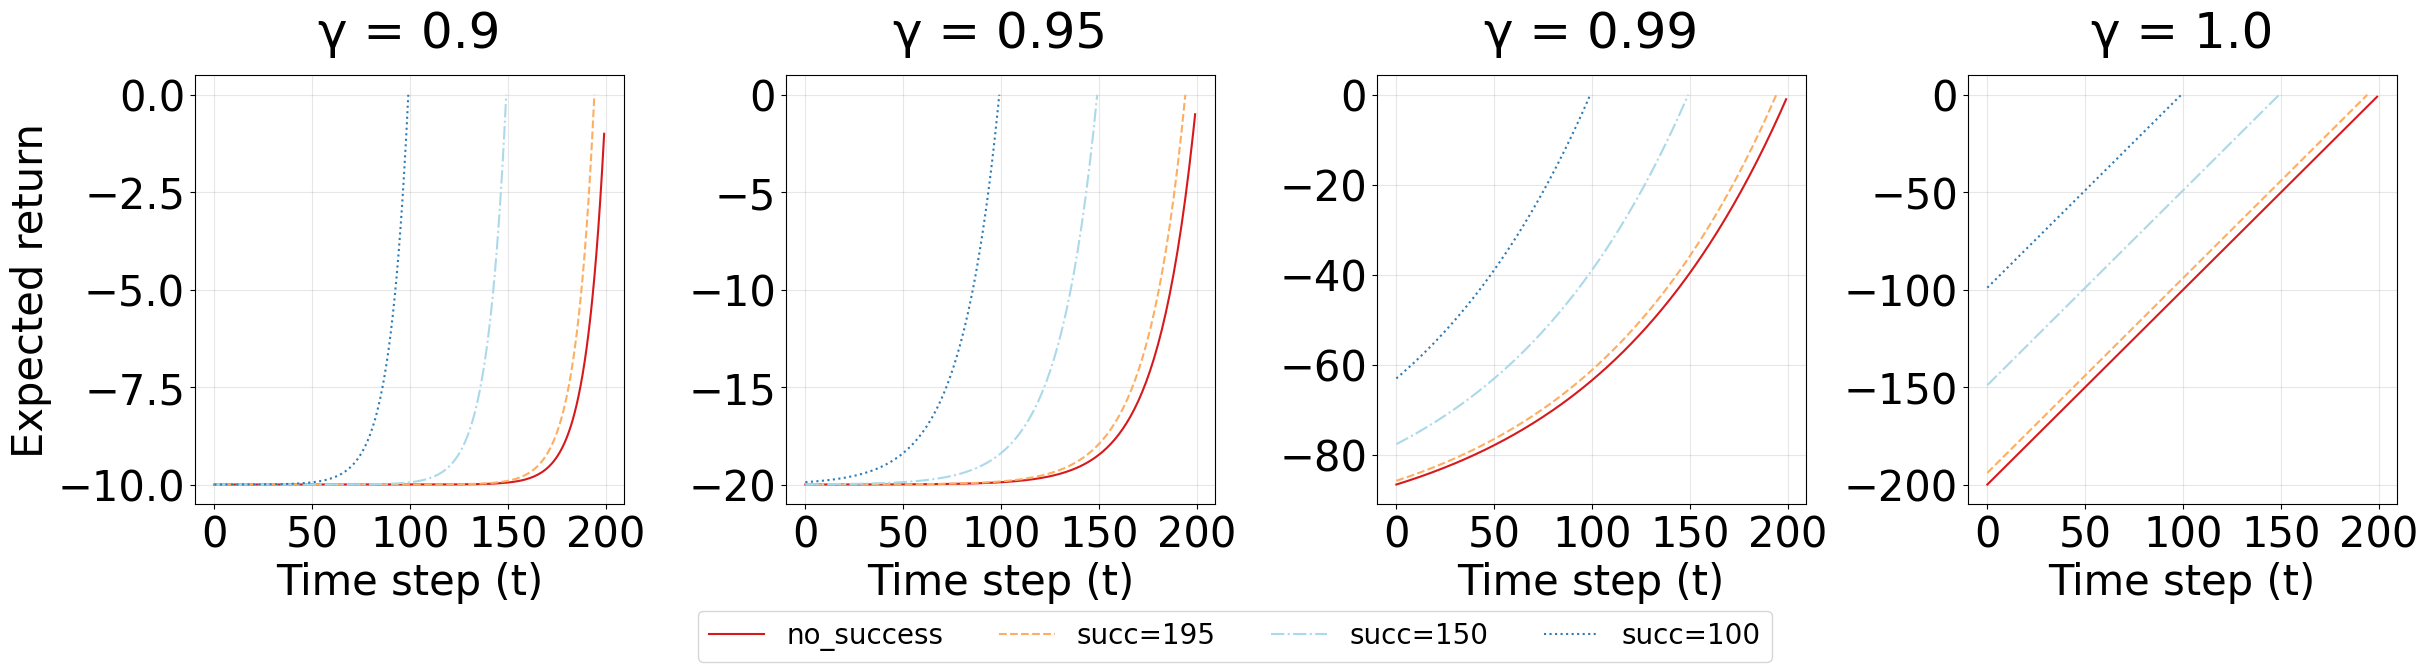

In [4]:
plot_lines(
    df,
    facet_col="gamma",
    x_col="t",
    y_col=["no_success","succ=195","succ=150","succ=100"],
    xlabel="Time step (t)",
    ylabel="Expected return",
    title_formatter=lambda g: f"γ = {g}",
    xticks=np.arange(0, 201, 50),
    tick_labelsize=30,
    title_fontsize=36,
    title_pad=20,
    label_fontsize=30,
    legend_fontsize=20,
    save_file_path="notebook_figures/chapter1/expected_returns_mountaincar.pdf",
)

## 2. A Q-Learning implementation and one training example (Section 1.2.2 of the manuscript)


Import some librariesrs

In [5]:
import gymnasium as gym

from matplotlib import animation
from IPython.display import HTML
import matplotlib.colors as mcolors

import random
from collections import deque

import seaborn as sns
from abc import ABC, abstractmethod

Create a abstract class for any training agent

In [6]:
class Agent(ABC):
    def __init__(self):
        pass

    def init_on_environment(self, observation_space, action_space):
        self.observation_space = observation_space
        self.action_space = action_space

    
    @abstractmethod
    def execute(self, state, training=False):
        pass

    @abstractmethod
    def remember(self, state, action, reward, next_state, execution_info):
        pass

    @abstractmethod
    def update(self):
        pass

    @abstractmethod
    def get_additional_metrics(self):
        pass

    @abstractmethod
    def after_train_clean(self):
        pass

Create a buffer class to collect transitions

In [7]:
class ReplayBuffer:
    def __init__(self, max_size, batch_size):
        self.batch_size = batch_size
        self.buffer = deque(maxlen=max_size)
        self.global_index = 0

    def add(self, state, action, reward, next_state, done):
        self.global_index += 1
        self.buffer.append(
            (np.array(state), action, reward, np.array(next_state), done)
        )

    def sample(self):
        n = len(self.buffer)

        indices = np.random.randint(0, n, size=self.batch_size)

        # build arrays directly (no deque indexing loop)
        states = []
        actions = []
        rewards = []
        next_states = []
        dones = []

        buf = self.buffer  # local binding = faster

        for i in indices:
            s, a, r, s2, d = buf[i]
            states.append(s)
            actions.append(a)
            rewards.append(r)
            next_states.append(s2)
            dones.append(d)

        return (
            np.asarray(states),
            np.asarray(actions),
            np.asarray(rewards),
            np.asarray(next_states),
            np.asarray(dones),
        )

    def __len__(self):
        return len(self.buffer)

    def clear(self):
        self.buffer.clear()

Create the QLearning class

In [8]:
class QLearning(Agent):
    def __init__(self, num_bins, lr, gamma, epsilon, zero_init = False, buffer=ReplayBuffer(1000, 10), replay_freq = 1):
        super().__init__()
        self.num_bins = num_bins

        self.lr = lr
        self.gamma = gamma
        self.epsilon = epsilon

        self.zero_init = zero_init      

        self.buffer = buffer
        self.replay_freq = replay_freq  


    def init_on_environment(self, observation_space, action_space):
        super().init_on_environment(observation_space, action_space)
        
        self.tuple_bins = observation_space.shape[0]*(self.num_bins,)
        self.upper_bounds = np.clip(observation_space.high, -10, 10)
        self.lower_bounds = np.clip(observation_space.low, -10, 10)

        if self.zero_init:
            self.q_table = np.zeros(self.tuple_bins + (action_space.n,))
        else:
            # Random table with sparse values
            self.q_table = (np.random.random(self.tuple_bins + (action_space.n,)) - 0.5) * 2000

        self.visit_table = np.zeros(self.tuple_bins)


    def discretize_state(self, state):

        # Calculate ratios and new state in one vectorized operation
        ratios = (np.array(state) - self.lower_bounds) / (self.upper_bounds - self.lower_bounds)
        new_state = np.round((np.array(self.tuple_bins) - 1) * ratios).astype(int)

        # Clip values to stay within bounds
        new_state = np.clip(new_state, 0, np.array(self.tuple_bins) - 1)

        return tuple(new_state)
    
    def execute(self, state, training=False):
        state_discrete = self.discretize_state(state)

        
        if training and np.random.random() < self.epsilon:
            action =  self.action_space.sample()
        else:
            action = np.argmax(self.q_table[state_discrete])
        
        return action, (state_discrete,)
    
    def remember(self, state, action, reward, next_state, terminated, execution_info):
        self.buffer.add(execution_info[0], action, reward, self.discretize_state(next_state), terminated)

    def update(self):
        if len(self.buffer) < self.buffer.batch_size or self.buffer.global_index % self.replay_freq != 0:
            return

        states, actions, rewards, next_states, dones = self.buffer.sample()

        state_idx = tuple(states.T)
        next_state_idx = tuple(next_states.T)

        self.visit_table[state_idx] += 1

        best_future_qs = np.max(
            self.q_table[next_state_idx],
            axis=-1
        )

        current_qs = self.q_table[
            state_idx + (actions,)
        ]

        targets = rewards + self.gamma * best_future_qs * (1 - dones)

        self.q_table[state_idx + (actions,)] += self.lr * (targets - current_qs)

    def get_additional_metrics(self):
        visited_mask = self.visit_table > 0

        if not np.any(visited_mask):
            return None

        visited_q = self.q_table[visited_mask]

        return {
            "q_mean": float(np.mean(visited_q)),
            "q_min": float(np.min(visited_q)),
            "q_max": float(np.max(visited_q)),
            "visited_bins": int(np.sum(visited_mask)),
        }
    
    def after_train_clean(self):
        self.buffer.clear()

Create a training class, that 

In [9]:
class TrainingAgent():
    def __init__(self, agent:Agent, environment:gym.Env, seed=0):
        self.agent = agent
        self.environment = environment

        self.max_step = None if environment.spec.id != "LunarLander-v3" else 500

        self.seed = seed
        np.random.seed(seed)
        random.seed(seed)

        self.agent.init_on_environment(self.environment.observation_space, self.environment.action_space)


        self.train_logs = list()
        self.valid_logs = list()

    def run_episode(self, seed=0, training=False):
        state, _ = self.environment.reset(seed = seed)
        done = False
        total_reward = 0

        nb_step = 0
        while not done:

            action, execution_info = self.agent.execute(state, training)

            next_state, reward, terminated, truncated, _ = self.environment.step(action)
            done = terminated or truncated


            nb_step += 1
            if self.max_step is not None and nb_step == self.max_step:
                truncated = True

            if training:
                self.agent.remember(state, action, reward, next_state, done, execution_info)
                self.agent.update()

            state = next_state

            total_reward += reward


        return total_reward
    
    def valid(self, nb_valid_episodes = 10, init_seed=0):
        score = 0
        for index_episode in range(nb_valid_episodes):
            score += self.run_episode(seed = init_seed + index_episode, training=False)
        return score / nb_valid_episodes
    
    def add_log(self, index_episode, score, type_score, smoothing, verbose):
        logs = self.train_logs if type_score == "train" else self.valid_logs

        # Average of the current score and the previous smoothing-1 scores
        recent_scores = [log["score"] for log in logs[-(smoothing - 1):]]
        smooth_score = (sum(recent_scores) + score) / (len(recent_scores) + 1)

        main_log = {
            "index_episode": index_episode,
            "score": score,
            "smooth_score": smooth_score,
        }

        if type_score != "valid":
            agent_log = self.agent.get_additional_metrics()
            if agent_log is not None:
                main_log = main_log | agent_log

        logs.append(main_log)

        if verbose and (verbose == 2 or type_score == "valid"):
            if type_score == "valid":
                train = self.train_logs[-1]
                print(f"episode={index_episode} --- TRAIN - last={train['score']:.3f} - smooth={train['smooth_score']:.3f} --- VALID last={score:.3f} - smooth={smooth_score:.3f}", end="\n" if index_episode%1000==0 else "\r", flush=True)
            elif verbose == 2 and type_score == "train":
                print(f"episode={index_episode} --- TRAIN - last={type_score}={score:.3f} - smooth={smooth_score:.3f}", end="\n" if index_episode%1000==0 else "\r", flush=True)

    def logs_to_df(self):
        train_df = pd.DataFrame(self.train_logs).rename(columns={"score": "train_score", "smooth_score": "train_smooth_score"})
        valid_df = pd.DataFrame(self.valid_logs).rename(columns={"score": "valid_score", "smooth_score": "valid_smooth_score"})

        # merge on episode index
        df = train_df.merge(valid_df, on="index_episode", how="outer").sort_values("index_episode")

        return df

    def train(self, nb_train_episodes=10, verbose = 1, freq_validate = 5, nb_valid_episodes = 10, smooth_train = 100, smooth_valid = 10):

        for index_episode in range(nb_train_episodes):
            # Training
            train_score = self.run_episode(seed=index_episode, training=True)
            self.add_log(index_episode, train_score, "train", smooth_train, verbose)

            # Validation
            if index_episode % freq_validate == 0 or index_episode == nb_train_episodes - 1:
                valid_score = self.valid(nb_valid_episodes, 2**62)
                self.add_log(index_episode, valid_score, "valid", smooth_valid, verbose)
        
        self.agent.after_train_clean()


In [10]:
qlearning_agent = QLearning(num_bins=20, lr=0.03, gamma=0.99, epsilon=0.1, zero_init=True, buffer=ReplayBuffer(1, 1), replay_freq=1)
mountainCar = gym.make("MountainCar-v0")

q_learning_job = TrainingAgent(qlearning_agent, mountainCar, 3)
q_learning_job.train(nb_train_episodes=10000, verbose=1, freq_validate=10, nb_valid_episodes=10, smooth_train = 100, smooth_valid = 10)

episode=0 --- TRAIN - last=-200.000 - smooth=-200.000 --- VALID last=-200.000 - smooth=-200.000
episode=1000 --- TRAIN - last=-200.000 - smooth=-199.780 --- VALID last=-197.600 - smooth=-196.510
episode=2000 --- TRAIN - last=-200.000 - smooth=-200.000 --- VALID last=-196.800 - smooth=-197.700
episode=3000 --- TRAIN - last=-200.000 - smooth=-200.000 --- VALID last=-200.000 - smooth=-200.000
episode=4000 --- TRAIN - last=-165.000 - smooth=-183.460 --- VALID last=-172.900 - smooth=-175.690
episode=5000 --- TRAIN - last=-200.000 - smooth=-186.940 --- VALID last=-196.000 - smooth=-177.240
episode=6000 --- TRAIN - last=-151.000 - smooth=-173.630 --- VALID last=-162.100 - smooth=-165.990
episode=7000 --- TRAIN - last=-160.000 - smooth=-165.720 --- VALID last=-152.700 - smooth=-156.590
episode=8000 --- TRAIN - last=-199.000 - smooth=-180.730 --- VALID last=-169.800 - smooth=-161.040
episode=9000 --- TRAIN - last=-184.000 - smooth=-165.150 --- VALID last=-168.600 - smooth=-160.190


Get log dataframe and print metrics

In [11]:
df_q_learning_job = q_learning_job.logs_to_df()
df_q_learning_job["environment"] = "MountainCar"
df_q_learning_job["agent"] = "Q-Learning"

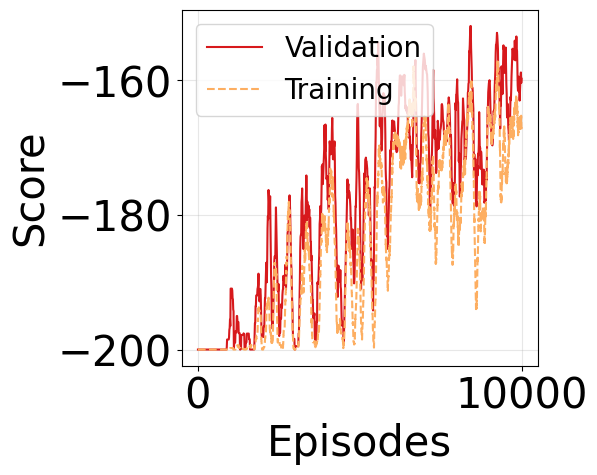

In [12]:
plot_lines(
    df_q_learning_job,
    x_col="index_episode",
    y_col=["valid_smooth_score", "train_smooth_score"],
    xlabel="Episodes",
    ylabel="Score",
    tick_labelsize=30,
    title_fontsize=36,
    title_pad=20,
    label_fontsize=30,
    legend_fontsize=20,
    save_file_path="notebook_figures/chapter1/q_learning_score.pdf",
    labels=["Validation", "Training"],
    legend_in=True
)

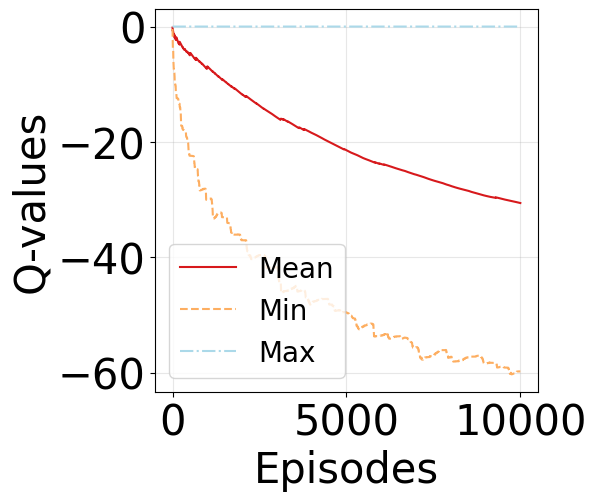

In [13]:
plot_lines(
    df_q_learning_job,
    x_col="index_episode",
    y_col=["q_mean", "q_min", "q_max"],
    xlabel="Episodes",
    ylabel="Q-values",
    tick_labelsize=30,
    title_fontsize=36,
    title_pad=20,
    label_fontsize=30,
    legend_fontsize=20,
    save_file_path="notebook_figures/chapter1/q_learning_q_values.pdf",
    n_col_legend=1,
    labels=["Mean", "Min", "Max"],
    legend_in=True
)

Method for ploting heatmap

In [14]:
from mpl_toolkits.axes_grid1 import make_axes_locatable
def q_visualisation_base(agent, data, cmap, norm=None, colorbar_ticks=None, colorbar_labels=None, colorbar_label="", title_save=None):

    masked_values = np.ma.masked_where(agent.visit_table < 1, data)

    fig, ax = plt.subplots(figsize=(6, 6))

    im = ax.imshow(masked_values.T, origin='lower', aspect='auto', cmap=cmap, norm=norm,
                   extent=[agent.lower_bounds[0], agent.upper_bounds[0],
                           agent.lower_bounds[1], agent.upper_bounds[1]])

    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.15)

    cbar = fig.colorbar(im, cax=cax, ticks=colorbar_ticks)
    cbar.ax.tick_params(labelsize=20)

    if colorbar_labels is not None:
        cbar.set_ticks(colorbar_ticks)
        cbar.set_ticklabels(colorbar_labels)
        cbar.ax.tick_params(labelsize=20)

    cbar.set_label(colorbar_label)

    ax.tick_params(axis='both', which='major', labelsize=30)
    ax.set_xticks(np.linspace(-1.2, 0.6, 4))
    ax.set_yticks(np.linspace(-0.07, 0.07, 5))

    ax.set_xlabel("Position", fontsize=30)
    ax.set_ylabel("Velocity", fontsize=30)

    if title_save is not None:
        plt.savefig(title_save, dpi=300, bbox_inches='tight')

    plt.show()

Plot Heatmap of Q-Values for the visited states

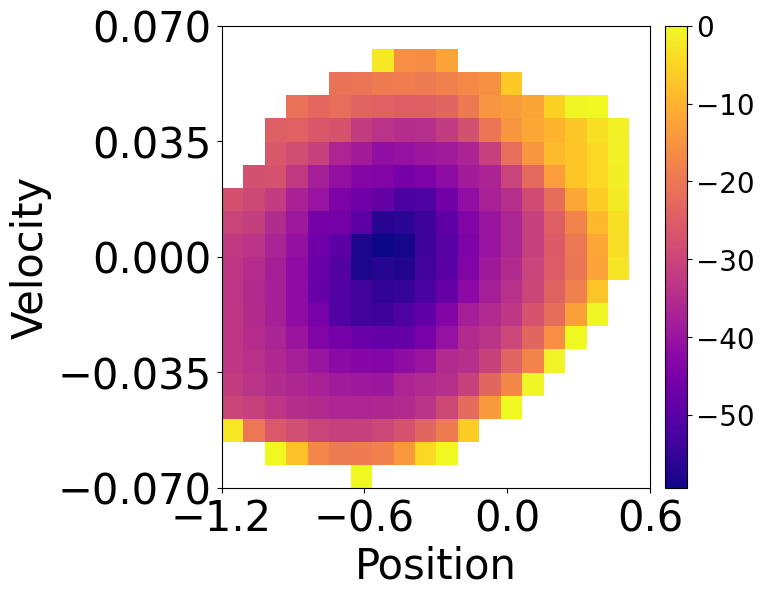

In [15]:
value_function = np.max(qlearning_agent.q_table, axis=-1)
cmap = mpl.cm.plasma.copy()

q_visualisation_base(qlearning_agent, data=value_function, cmap=cmap, colorbar_label="", title_save="notebook_figures/chapter1/q_learning_q_value_heatmap.pdf")

Plot Heatmap of greedy policy for the visited states

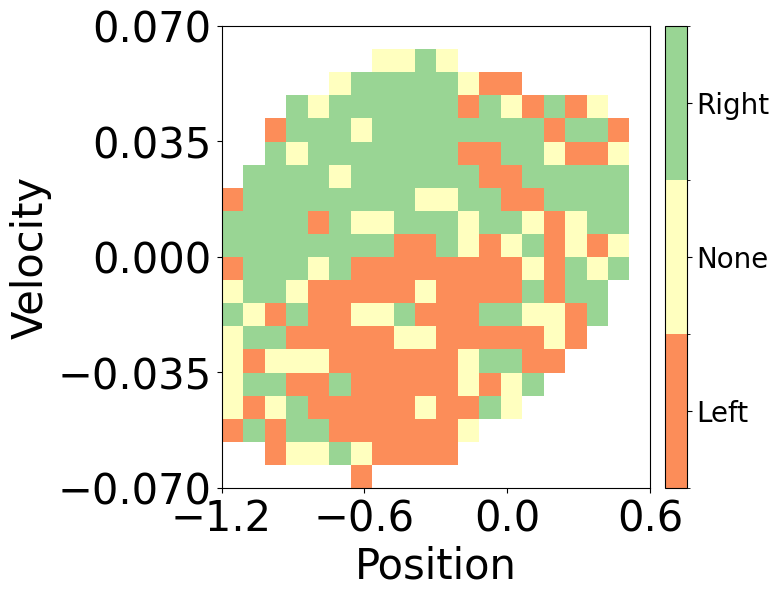

In [16]:

policy = np.argmax(qlearning_agent.q_table, axis=-1)

cmap = mcolors.ListedColormap(["#fc8d59", "#ffffbf", "#99d594"])
bounds = [-0.5, 0.5, 1.5, 2.5]
norm = mcolors.BoundaryNorm(bounds, cmap.N)

q_visualisation_base(qlearning_agent, data=policy, cmap=cmap, norm=norm, colorbar_ticks=[0, 1, 2], colorbar_labels=["Left", "None", "Right"], colorbar_label="", title_save="notebook_figures/chapter1/q_learning_policy.pdf")

In [17]:
def test(agent:Agent, env_name, seed=0, animate=True,verbose=True):
    test_env = gym.make(env_name, render_mode='rgb_array')
    frames = []

    state, _ = test_env.reset(seed=seed)
    total_reward = 0

    while True:
        action = agent.execute(state)[0]
        next_state, reward, terminated, truncated, _ = test_env.step(action)
        done = terminated or truncated

        state = next_state
        total_reward += reward
        frames.append(test_env.render())

        if done:
            break

    test_env.close()
    if(verbose):
        print(total_reward)

    if animate:
        fig = plt.figure(figsize=(8, 6))
        patch = plt.imshow(frames[0])
        plt.axis('off')

        def animate_frame(i):
            patch.set_data(frames[i])

        anim = animation.FuncAnimation(
            fig,
            animate_frame,
            frames=len(frames),
            interval=20,
        )

        plt.close(fig)
        display(HTML(anim.to_jshtml()))
    
    return total_reward

Testing method

In [ ]:
test(qlearning_agent, "MountainCar-v0", 4, True)

## 3. A Deep Q-Network implementation and one training example (Section 1.3.1 of the manuscript)


Import useful libraries

In [19]:
import torch
mpl.rcParams['animation.embed_limit'] = 50

Create NN used class

In [20]:
class Network(torch.nn.Module):
    def __init__(self, input_dim, output_dim, hidden_layer, hidden_size):
        super().__init__()

        layers = []
        # Input layer
        layers.append(torch.nn.Linear(input_dim, hidden_size))
        layers.append(torch.nn.ReLU())

        # Hidden layers
        for _ in range(hidden_layer - 1):
            layers.append(torch.nn.Linear(hidden_size, hidden_size))
            layers.append(torch.nn.ReLU())

        # Output layer
        layers.append(torch.nn.Linear(hidden_size, output_dim))

        self.net = torch.nn.Sequential(*layers)
        

    def forward(self, x):
        return self.net(x)

DQN class

In [21]:
class DQN(Agent):
    def __init__(self, lr=0.003, gamma=0.99, epsilon=0.1, hidden_layer=2, hidden_size=64, target_network_update_freq=1000, replay_freq=1, buffer=ReplayBuffer(1000, 32)):
        
        super().__init__()
        self.lr = lr
        self.gamma = gamma
        self.epsilon = epsilon

        self.target_network_update_freq = target_network_update_freq

        self.hidden_layer = hidden_layer
        self.hidden_size = hidden_size

        self.buffer = buffer
        self.replay_freq = replay_freq

        self.current_loss = None

    def init_on_environment(self, observation_space, action_space):
        super().init_on_environment(observation_space, action_space)
        
        self.action_dim = action_space.n
        self.obs_dim = observation_space.shape[0]

        self.q_network = Network(self.obs_dim, self.action_dim, self.hidden_layer, self.hidden_size)
        self.target_network = Network(self.obs_dim, self.action_dim, self.hidden_layer, self.hidden_size)
        self.target_network.load_state_dict(self.q_network.state_dict())

        self.optimizer = torch.optim.Adam(self.q_network.parameters(), lr=self.lr)
        self.loss_fn = torch.nn.MSELoss()
    
    def execute(self, state, training=False):

        if training and np.random.random() < self.epsilon:
            return self.action_space.sample(), None

        state_tensor = torch.tensor(state, dtype=torch.float32).unsqueeze(0)
        with torch.no_grad():
            q_values = self.q_network(state_tensor)
        return int(torch.argmax(q_values).item()), None
    
    def remember(self, state, action, reward, next_state, terminated, execution_info):
        self.buffer.add(state, action, reward, next_state, terminated)

    def update(self):
        if len(self.buffer) < self.buffer.batch_size or self.buffer.global_index % self.replay_freq != 0:
            return None

        states, actions, rewards, next_states, dones = self.buffer.sample()

        states_tensor = torch.tensor(states, dtype=torch.float32)
        next_states_tensor = torch.tensor(next_states, dtype=torch.float32)
        actions_tensor = torch.tensor(actions, dtype=torch.long)
        rewards_tensor = torch.tensor(rewards, dtype=torch.float32)
        dones_tensor = torch.tensor(dones, dtype=torch.float32)

        current_q = self.q_network(states_tensor).gather(1, actions_tensor.unsqueeze(1)).squeeze(1)

        with torch.no_grad():
            next_q = self.target_network(next_states_tensor).max(dim=1)[0]
            target_q = rewards_tensor + self.gamma * next_q * (1 - dones_tensor)

        loss = self.loss_fn(current_q, target_q)
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        

        if self.buffer.global_index % (self.target_network_update_freq * self.replay_freq) == 0:
            self.target_network.load_state_dict(self.q_network.state_dict())

        self.current_loss = loss.item()

    def get_additional_metrics(self):
        if self.current_loss is None:
            return self.current_loss
        return {"loss": self.current_loss}

    def after_train_clean(self):
        self.buffer.clear()
        self.optimizer = None
        self.target_network = None

In [22]:
dqn_agent = DQN(lr=0.003, gamma=0.99, epsilon=0.1, hidden_layer=2, hidden_size=64, target_network_update_freq=5000, buffer=ReplayBuffer(100000, 32), replay_freq=1)

dqn_mountain_job = TrainingAgent(dqn_agent, mountainCar, 1)
dqn_mountain_job.train(nb_train_episodes=5_000, verbose=1, freq_validate=10, nb_valid_episodes=10, smooth_train = 100, smooth_valid = 10)

episode=0 --- TRAIN - last=-200.000 - smooth=-200.000 --- VALID last=-200.000 - smooth=-200.000
episode=1000 --- TRAIN - last=-200.000 - smooth=-187.470 --- VALID last=-200.000 - smooth=-179.320
episode=2000 --- TRAIN - last=-156.000 - smooth=-162.740 --- VALID last=-131.300 - smooth=-150.420
episode=3000 --- TRAIN - last=-171.000 - smooth=-193.540 --- VALID last=-163.200 - smooth=-192.590
episode=4000 --- TRAIN - last=-143.000 - smooth=-150.660 --- VALID last=-164.200 - smooth=-139.680


In [23]:
dqn_agent = DQN(lr=0.003, gamma=0.99, epsilon=0.1, hidden_layer=2, hidden_size=64, target_network_update_freq=5000, buffer=ReplayBuffer(100000, 32), replay_freq=1)
lunarLander = gym.make("LunarLander-v3")

dqn_lunar_job = TrainingAgent(dqn_agent, lunarLander, 1)
dqn_lunar_job.train(nb_train_episodes=5_000, verbose=1, freq_validate=10, nb_valid_episodes=10, smooth_train = 100, smooth_valid = 10)

episode=0 --- TRAIN - last=-278.814 - smooth=-278.814 --- VALID last=-802.988 - smooth=-802.988
episode=1000 --- TRAIN - last=-2.919 - smooth=191.094 --- VALID last=253.194 - smooth=192.4022930
episode=2000 --- TRAIN - last=93.110 - smooth=175.198 --- VALID last=223.439 - smooth=210.831857
episode=3000 --- TRAIN - last=297.791 - smooth=205.338 --- VALID last=42.159 - smooth=186.40838
episode=4000 --- TRAIN - last=244.602 - smooth=162.134 --- VALID last=132.018 - smooth=104.4375


In [ ]:
test(dqn_lunar_job.agent, "LunarLander-v3", 0, True)

Get dataframe and plot scores

In [25]:
df_dqn_lunar_job = dqn_lunar_job.logs_to_df()
df_dqn_mountain_job = dqn_mountain_job.logs_to_df()

df_dqn_lunar_job["environment"] = "LunarLander"
df_dqn_mountain_job["environment"] = "MountainCar"
df_dqn_job = pd.concat((df_dqn_lunar_job, df_dqn_mountain_job), axis=0)

df_dqn_job["agent"] = "DQN"
df_all = pd.concat((df_dqn_job, df_q_learning_job), axis=0)

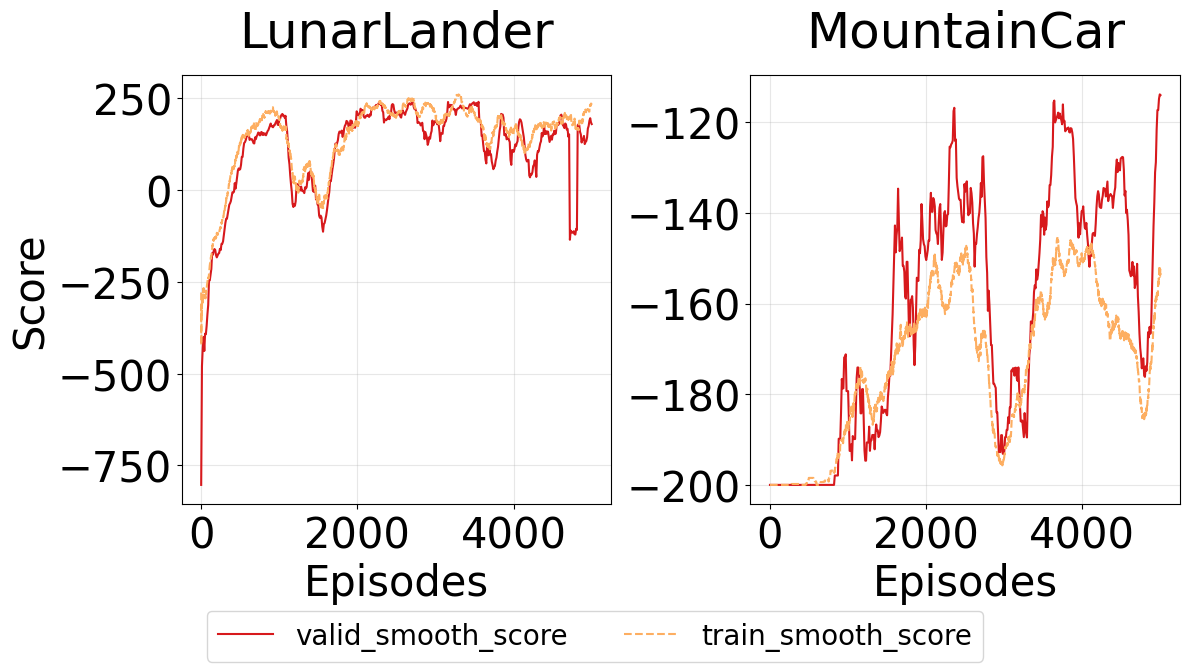

In [26]:
plot_lines(
    df_dqn_job,
    facet_col="environment",
    x_col="index_episode",
    y_col=["valid_smooth_score", "train_smooth_score"],
    xlabel="Episodes",
    ylabel="Score",
    tick_labelsize=30,
    title_fontsize=36,
    title_pad=20,
    label_fontsize=30,
    legend_fontsize=20,
    save_file_path="notebook_figures/chapter1/dqn_score.pdf",
)

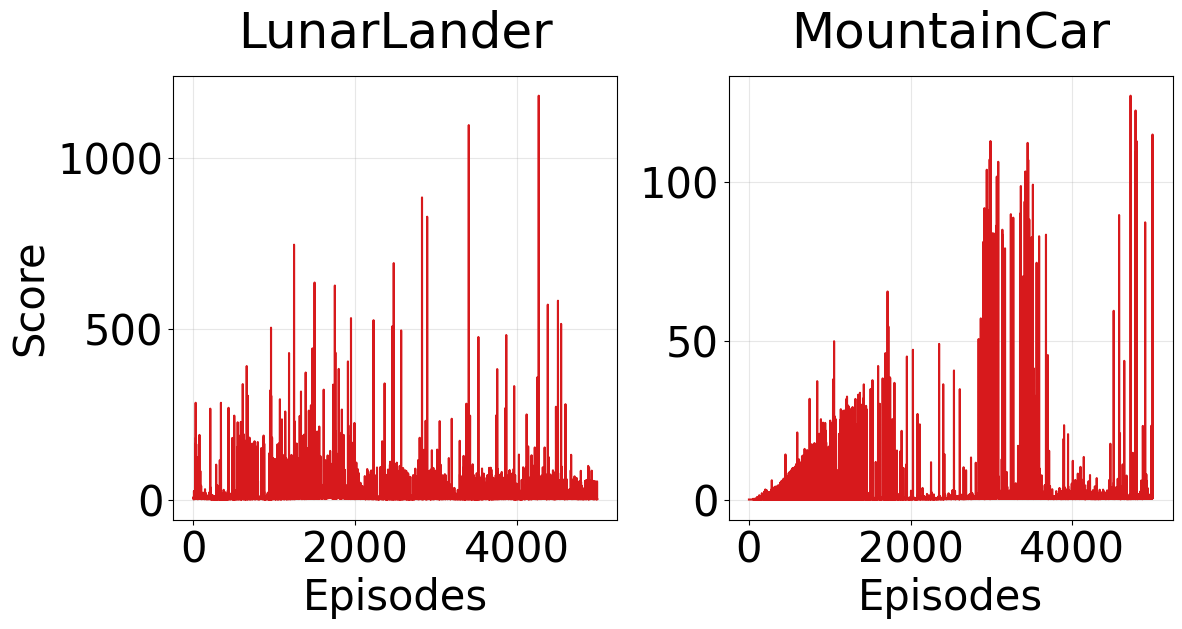

In [27]:
plot_lines(
    df_dqn_job,
    facet_col="environment",
    x_col="index_episode",
    y_col=["loss"],
    xlabel="Episodes",
    ylabel="Score",
    tick_labelsize=30,
    title_fontsize=36,
    title_pad=20,
    label_fontsize=30,
    legend_fontsize=20,
    save_file_path="notebook_figures/chapter1/dqn_loss.pdf",
)

## 4. A PPO implementation and one training example (Section 1.3.3 of the manuscript)


Rollout Buffer class (different from replay buffer as it compute directly the GAE estimation)

In [28]:

class RolloutBuffer:
    def __init__(self):
        self.states, self.actions = [], []
        self.rewards, self.dones = [], []
        self.log_probs, self.values = [], []

    def add(self, s, a, r, done, logp, value):
        self.states.append(s)
        self.actions.append(a)
        self.rewards.append(r)
        self.dones.append(done)
        self.log_probs.append(logp)
        self.values.append(value)

    def compute_gae(self, last_value, gamma, lambda_):
        values = np.array(self.values + [last_value])
        rewards = np.array(self.rewards)
        dones = np.array(self.dones, dtype=bool)

        advantages = np.zeros(len(rewards))
        gae = 0

        for t in reversed(range(len(rewards))):
            delta = rewards[t] + gamma * values[t+1] * (1 - dones[t]) - values[t]
            gae = delta + gamma * lambda_ * (1 - dones[t]) * gae
            advantages[t] = gae

        returns = advantages + values[:-1]

        # Standardization
        self.advantages = (
            advantages - advantages.mean()
        ) / (advantages.std() + 1e-8)

        self.returns = returns

    def __len__(self):
        return len(self.states)

    def clear(self):
        self.__init__()

PPO class

In [29]:
class PPO(Agent):
    def __init__(self, lr, gamma, gae_lambda, clip, coef_entropy, nb_epochs, batch_size, hidden_layer, hidden_size, rollout_size):
        super().__init__()
        self.lr = lr
        self.gamma = gamma
        self.gae_lambda = gae_lambda
        self.clip = clip
        self.coef_entropy = coef_entropy

        self.rollout_size = rollout_size
        self.buffer = RolloutBuffer()

        self.batch_size = batch_size
        self.nb_epochs = nb_epochs

        self.hidden_layer = hidden_layer
        self.hidden_size = hidden_size

        self.current_actor_loss = None
        self.current_critic_loss = None

        self.last_next_state = None
        self.last_done = None

    def init_on_environment(self, observation_space, action_space):
        super().init_on_environment(observation_space, action_space)
        
        self.obs_dim = observation_space.shape[0]

        self.is_continuous = hasattr(action_space, "shape") and len(action_space.shape) > 0

        if self.is_continuous:
            self.action_dim = action_space.shape[0]
            self.action_high = torch.tensor(action_space.high, dtype=torch.float32)
            self.action_low = torch.tensor(action_space.low, dtype=torch.float32)

            self.log_std = torch.nn.Parameter(torch.zeros(self.action_dim))
        else:
            self.action_dim = action_space.n


        self.critic = Network(self.obs_dim, 1, self.hidden_layer, self.hidden_size)

        self.critic_optimizer = torch.optim.Adam(self.critic.parameters(), lr=self.lr)
        self.loss_fn = torch.nn.MSELoss()

        self.actor = Network(self.obs_dim, self.action_dim, self.hidden_layer, self.hidden_size)
        if self.is_continuous:
            self.actor_optimizer = torch.optim.Adam(list(self.actor.parameters()) + [self.log_std], lr=self.lr)
        else:
            self.actor_optimizer = torch.optim.Adam(self.actor.parameters(), lr=self.lr)


    
    def execute(self, state, training=False):

        state_tensor = torch.tensor(state, dtype=torch.float32).unsqueeze(0)

        with torch.no_grad():

            logits_or_mean = self.actor(state_tensor)

        if self.is_continuous:

            mean = logits_or_mean
            std = torch.exp(self.log_std).unsqueeze(0)

            dist = torch.distributions.Normal(mean, std)

            if training:

                u = dist.rsample()
                action = torch.tanh(u) * self.action_high

                # log-prob
                log_prob = dist.log_prob(u).sum(dim=-1)
                value = self.critic(state_tensor)

                return action.squeeze(0).detach().numpy(), (u.squeeze(0).detach().numpy(), log_prob.item(), value.item())

            else:

                u = mean  # deterministic mean action at test time
                action = torch.tanh(u)
                action = action * self.action_high

                return action.squeeze(0).detach().numpy(), None

        else:
            dist = torch.distributions.Categorical(logits=logits_or_mean)

            if training:
                action = dist.sample()
                log_prob = dist.log_prob(action)
                value = self.critic(state_tensor)

                return action.item(), (action.item(), log_prob.item(), value.item())

            else:
                return torch.argmax(logits_or_mean, dim=-1).item(), None
        
    
    def remember(self, state, action, reward, next_state, terminated, execution_info):
        self.last_next_state = next_state
        self.last_done = terminated
        self.buffer.add(state, execution_info[0], reward, terminated, execution_info[1], execution_info[2])


    def update(self):

        if len(self.buffer) < self.rollout_size:
            return

        last_value = 0 if self.last_done else self.critic(torch.tensor(self.last_next_state, dtype=torch.float32).unsqueeze(0)).detach().item()
        self.buffer.compute_gae(last_value, self.gamma, self.gae_lambda)

        for _ in range(self.nb_epochs):
            # Shuffle indices at the start of each epoch
            indices = np.random.permutation(len(self.buffer))

            for batch_start in range(0, len(self.buffer), self.batch_size):
                batch_end = batch_start + self.batch_size
                batch_indices = indices[batch_start:batch_end]

                # Get mini-batch data
                states = torch.tensor(np.array(self.buffer.states)[batch_indices], dtype=torch.float32)
                actions = torch.tensor(np.array(self.buffer.actions)[batch_indices], dtype=torch.float32 if self.is_continuous else torch.long)
                old_log_probs = torch.tensor(np.array(self.buffer.log_probs)[batch_indices], dtype=torch.float32)
                advantages = torch.tensor(self.buffer.advantages[batch_indices], dtype=torch.float32)
                returns = torch.tensor(self.buffer.returns[batch_indices], dtype=torch.float32)

                # --- Critic Update ---
                values = self.critic(states)
                critic_loss = self.loss_fn(values.squeeze(), returns)

                self.critic_optimizer.zero_grad()
                critic_loss.backward()
                self.critic_optimizer.step()

                # --- Actor Update ---
                logits_or_mean = self.actor(states)

                if self.is_continuous:

                    mean = logits_or_mean
                    std = torch.exp(self.log_std).unsqueeze(0)

                    dist = torch.distributions.Normal(mean, std)

                    new_log_probs = dist.log_prob(actions).sum(-1)
                    entropy = dist.entropy().sum(dim=-1)

                else:

                    dist = torch.distributions.Categorical(logits=logits_or_mean)

                    new_log_probs = dist.log_prob(actions)
                    entropy = dist.entropy()

                # PPO clipped objective
                ratio = torch.exp(new_log_probs - old_log_probs)

                surr1 = ratio * advantages
                surr2 = torch.clamp(ratio, 1.0 - self.clip, 1.0 + self.clip) * advantages

                actor_loss = -torch.min(surr1, surr2).mean()

                actor_loss -= self.coef_entropy * entropy.mean()

                self.actor_optimizer.zero_grad()
                actor_loss.backward()
                self.actor_optimizer.step()

                self.current_actor_loss = actor_loss.item()
                self.current_critic_loss = critic_loss.item()

        self.buffer.clear()

    def get_additional_metrics(self):
        if self.current_actor_loss is None or self.current_critic_loss is None:
            return None
        return {"actor_loss": self.current_actor_loss, "critic_loss": self.current_critic_loss}

    def after_train_clean(self):
        self.buffer.clear()
        self.critic_optimizer = None
        self.act_optimizer_optimizer = None
        self.last_next_state = None
        self.last_done = None
        

In [30]:
ppo_agent = PPO(lr=0.003, gamma=0.99, gae_lambda=0.95, clip=0.2, coef_entropy=0.1, nb_epochs=10, batch_size=64, hidden_layer=2, hidden_size=64, rollout_size=2048)

ppo_mountain_job = TrainingAgent(ppo_agent, mountainCar, 1)
ppo_mountain_job.train(nb_train_episodes=5000, verbose=1, freq_validate=10, nb_valid_episodes=10, smooth_train = 100, smooth_valid = 10)

episode=0 --- TRAIN - last=-200.000 - smooth=-200.000 --- VALID last=-200.000 - smooth=-200.000
episode=1000 --- TRAIN - last=-200.000 - smooth=-192.930 --- VALID last=-100.000 - smooth=-122.580
episode=2000 --- TRAIN - last=-168.000 - smooth=-143.180 --- VALID last=-106.900 - smooth=-108.990
episode=3000 --- TRAIN - last=-112.000 - smooth=-131.660 --- VALID last=-105.300 - smooth=-102.060
episode=4000 --- TRAIN - last=-130.000 - smooth=-137.550 --- VALID last=-106.000 - smooth=-105.150


In [31]:
ppo_agent = PPO(lr=0.003, gamma=0.99, gae_lambda=0.95, clip=0.2, coef_entropy=0.01, nb_epochs=10, batch_size=64, hidden_layer=2, hidden_size=64, rollout_size=2048)

ppo_lunar_job = TrainingAgent(ppo_agent, lunarLander, 1)
ppo_lunar_job.train(nb_train_episodes=5000, verbose=1, freq_validate=10, nb_valid_episodes=10, smooth_train = 100, smooth_valid = 10)

episode=0 --- TRAIN - last=-73.913 - smooth=-73.913 --- VALID last=-148.943 - smooth=-148.943
episode=1000 --- TRAIN - last=285.663 - smooth=136.530 --- VALID last=142.366 - smooth=176.436914
episode=2000 --- TRAIN - last=277.402 - smooth=157.543 --- VALID last=83.732 - smooth=85.50937570
episode=3000 --- TRAIN - last=-135.134 - smooth=215.622 --- VALID last=260.810 - smooth=178.928
episode=4000 --- TRAIN - last=205.348 - smooth=143.770 --- VALID last=178.446 - smooth=209.1242


In [32]:
ppo_agent = PPO(lr=0.0003, gamma=0.99, gae_lambda=0.95, clip=0.2, coef_entropy=0.01, nb_epochs=10, batch_size=64, hidden_layer=2, hidden_size=64, rollout_size=2048)
walker2d = gym.make("Walker2d-v5")

ppo_walker_job = TrainingAgent(ppo_agent, walker2d, 1)
ppo_walker_job.train(nb_train_episodes=10000, verbose=1, freq_validate=10, nb_valid_episodes=10, smooth_train = 100, smooth_valid = 10)

episode=0 --- TRAIN - last=15.912 - smooth=15.912 --- VALID last=8.968 - smooth=8.968
episode=1000 --- TRAIN - last=332.134 - smooth=310.896 --- VALID last=392.742 - smooth=334.607
episode=2000 --- TRAIN - last=1885.027 - smooth=740.138 --- VALID last=1820.356 - smooth=1956.739
episode=3000 --- TRAIN - last=1064.191 - smooth=999.653 --- VALID last=1979.003 - smooth=1707.5423
episode=4000 --- TRAIN - last=809.828 - smooth=954.712 --- VALID last=803.960 - smooth=969.4555012
episode=5000 --- TRAIN - last=257.205 - smooth=1510.631 --- VALID last=2789.563 - smooth=2621.4320
episode=6000 --- TRAIN - last=411.864 - smooth=1738.404 --- VALID last=2165.120 - smooth=2119.6810
episode=7000 --- TRAIN - last=1586.313 - smooth=1821.071 --- VALID last=2616.359 - smooth=2939.171
episode=8000 --- TRAIN - last=1458.067 - smooth=1993.761 --- VALID last=2781.736 - smooth=2779.215
episode=9000 --- TRAIN - last=1160.630 - smooth=2327.358 --- VALID last=3592.256 - smooth=3177.749


In [ ]:
test(ppo_agent, "Walker2d-v5", 0, False)
#I had to deactivate the gif because it was too large for github :()

In [34]:
df_ppo_lunar_job = ppo_lunar_job.logs_to_df()
df_ppo_mountain_job = ppo_mountain_job.logs_to_df()
df_ppo_walker_job = ppo_walker_job.logs_to_df()

df_ppo_lunar_job["environment"] = "LunarLander"
df_ppo_mountain_job["environment"] = "MountainCar"
df_ppo_walker_job["environment"] = "Walker2D"
df_ppo_job = pd.concat((df_ppo_lunar_job, df_ppo_mountain_job, df_ppo_walker_job), axis=0)

df_ppo_job["agent"] = "PPO"
df_all = pd.concat((df_ppo_job, df_all), axis=0)

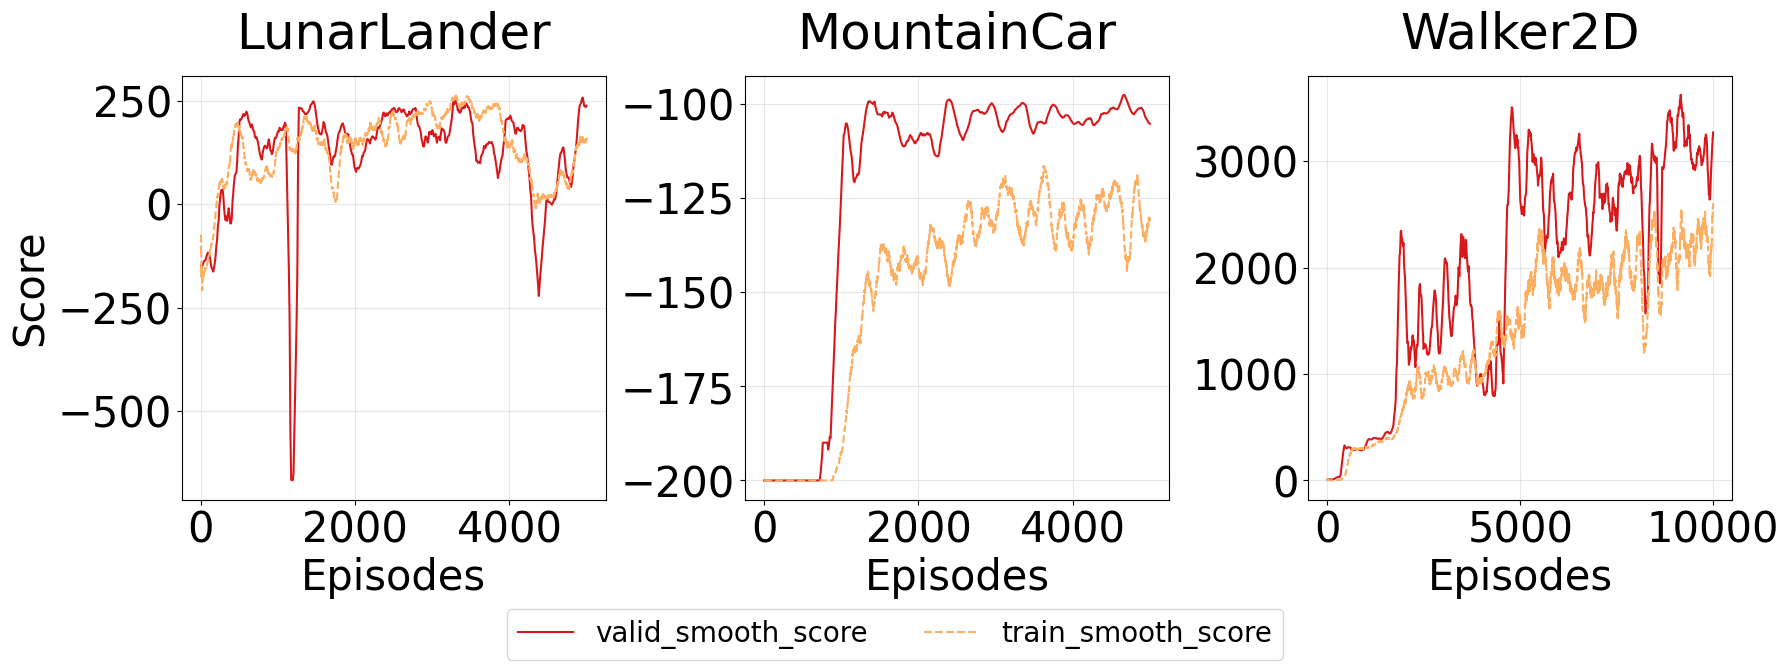

In [35]:
plot_lines(
    df_ppo_job,
    facet_col="environment",
    x_col="index_episode",
    y_col=["valid_smooth_score", "train_smooth_score"],
    xlabel="Episodes",
    ylabel="Score",
    tick_labelsize=30,
    title_fontsize=36,
    title_pad=20,
    label_fontsize=30,
    legend_fontsize=20,
    save_file_path="notebook_figures/chapter1/dqn_score.pdf",
)

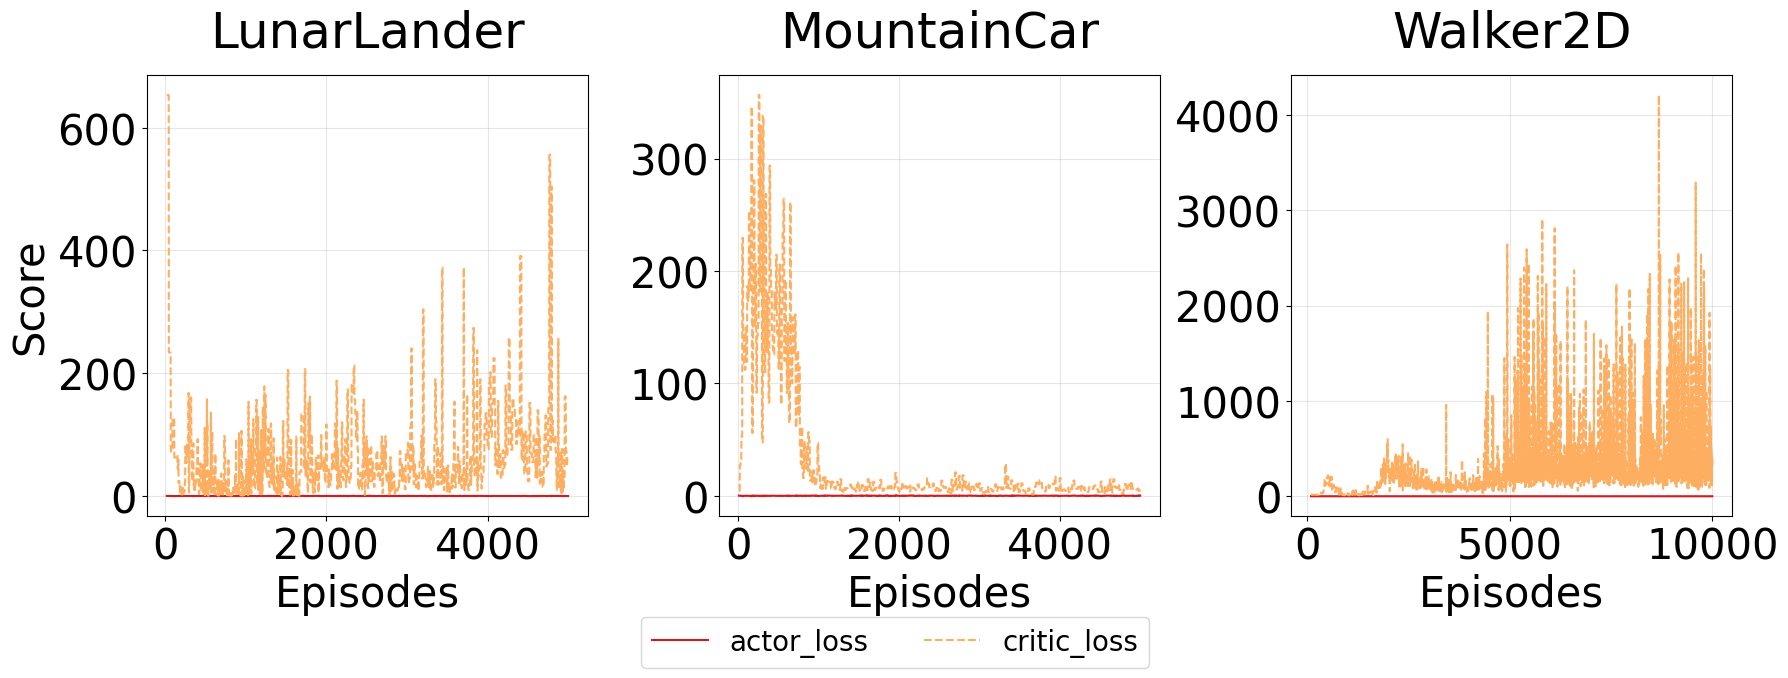

In [36]:
plot_lines(
    df_ppo_job,
    facet_col="environment",
    x_col="index_episode",
    y_col=["actor_loss", "critic_loss"],
    xlabel="Episodes",
    ylabel="Score",
    tick_labelsize=30,
    title_fontsize=36,
    title_pad=20,
    label_fontsize=30,
    legend_fontsize=20,
    save_file_path="notebook_figures/chapter1/dqn_score.pdf",
)

## 5. A final section to launch multiple training and draw comparison

In [ ]:
from joblib import Parallel, delayed
from itertools import product
import copy

# Set nb threads for DQN and PPO parallel training
torch.set_num_threads(1)

In [ ]:
def run_experiment(args):
    (params, nb_train_episodes, freq_validate, nb_valid_episodes) = args


    env = gym.make(params["env_name"])

    p = params["agent_params"]
    if params["agent_name"] == "QLearning":
        agent = QLearning(num_bins=p["num_bins"], lr=p["lr"], gamma=p["gamma"], epsilon=p["epsilon"], zero_init=p["zero_init"], 
                          buffer=ReplayBuffer(p["buffer_size"], p["batch_size"]), replay_freq=p["replay_freq"])

    if params["agent_name"] == "DQN":
        agent = DQN(lr=p["lr"], gamma=p["gamma"], epsilon=p["epsilon"], hidden_layer=p["hidden_layer"], hidden_size=p["hidden_size"], 
                    target_network_update_freq=p["t_net_freq"], buffer=ReplayBuffer(p["buffer_size"], p["batch_size"]), replay_freq=p["replay_freq"])

    if params["agent_name"] == "PPO":
        agent = PPO(lr=p["lr"], gamma=p["gamma"], gae_lambda=p["gae_lambda"], clip=p["clip"], coef_entropy=p["coef_entropy"], nb_epochs=p["nb_epochs"], 
                    batch_size=p["batch_size"], hidden_layer=p["hidden_layer"], hidden_size=p["hidden_size"], rollout_size=p["rollout_size"])

    env = gym.make(params["env_name"])

    job = TrainingAgent(agent, env, params["seed"])
    job.train(nb_train_episodes=nb_train_episodes, verbose=1, freq_validate=freq_validate, nb_valid_episodes=nb_valid_episodes, smooth_train = 100, smooth_valid = 10)

    env.close()


    return {
        "seed": params["seed"],
        "agent": agent,
        "agent_name": params["agent_name"],
        "agent_params": params["agent_params"],
        "env_name": params["env_name"],
        "logs": job.logs_to_df(),
    }

In [ ]:
def create_tasks(tasks, results, base_params, variations,
                 nb_train_episodes=10000,
                 freq_validate=10,
                 nb_valid_episodes=10):

    def make_signature(params):
        return (
            params["env_name"],
            params["agent_name"],
            params["seed"],
            tuple(sorted(params["agent_params"].items()))
        )

    # build set of already-run configs
    done = set()
    for r in results:
        params = {
            "env_name": r["env_name"],
            "agent_name": r["agent_name"],
            "seed": r["seed"],
            "agent_params": r["agent_params"]
        }
        done.add(make_signature(params))

    for params, *_ in tasks:
        done.add(make_signature(params))

    envs = variations["env_name"]
    agents = variations["agent_name"]
    seeds = variations["seed"]
    agent_grids = variations.get("agent_grids", {})

    nb_tasks_added = 0
    nb_tasks_skipped = 0

    for env in envs:
        for agent in agents:

            grid = agent_grids.get(agent, {})

            keys = list(grid.keys())
            values = list(grid.values())

            combos = list(product(*values)) if values else [()]

            for combo in combos:
                overrides = dict(zip(keys, combo))

                for seed in seeds:
                    params = copy.deepcopy(base_params)

                    params["env_name"] = env
                    params["agent_name"] = agent
                    params["seed"] = seed

                    # merge correct agent config
                    params["agent_params"] = copy.deepcopy(params[agent])
                    params["agent_params"].update(overrides)

                    sig = make_signature(params)

                    # skip if already trained
                    if sig in done:
                        nb_tasks_skipped += 1
                        continue

                    tasks.append(
                        (params, nb_train_episodes, freq_validate, nb_valid_episodes)
                    )

                    nb_tasks_added += 1
                    done.add(sig)
    print(f"Creation of task completed.\nAddition of {nb_tasks_added} tasks for a total of {len(tasks)}\nSkipped {nb_tasks_skipped} because dupplicated")

In [ ]:
def train_on_tasks(results, tasks, nb_jobs):

    print(f"Launching {len(tasks)} experiments")

    outputs = Parallel(
        n_jobs=nb_jobs,
        backend="loky",
        verbose=10
    )(
        delayed(run_experiment)(task)
        for task in tasks
    )

    results.extend(outputs)
    tasks.clear()

Plotting method

In [ ]:
def select_runs(results, env_name, agent_name, agent_params=None):
    runs = results.values() if isinstance(results, dict) else results

    out = []
    for r in runs:
        if r["env_name"] != env_name:
            continue

        if r["agent_name"] != agent_name:
            continue

        if agent_params is not None:
            if not all(
                r["agent_params"].get(k) == v
                for k, v in agent_params.items()
            ):
                continue

        out.append(r)

    return out


def aggregate_metric_over_seeds(runs, metric, x_col="index_episode"):
    frames = []

    for r in runs:
        logs = r.get("logs")
        if logs is None or metric not in logs.columns or x_col not in logs.columns:
            continue

        df = logs[[x_col, metric]].copy()
        df = df.dropna(subset=[metric])
        if df.empty:
            continue

        # In case the same episode appears multiple times in a run, keep one value per x_col
        df = df.groupby(x_col, as_index=False)[metric].mean()
        df["seed"] = r.get("seed", None)
        frames.append(df)

    if not frames:
        return pd.DataFrame(columns=[x_col, "mean", "std", "min", "max", "count"])

    all_df = pd.concat(frames, ignore_index=True)

    agg = (
        all_df.groupby(x_col)[metric]
        .agg(mean="mean", std="std", min="min", max="max", count="count")
        .reset_index()
        .sort_values(x_col)
    )

    return agg


def plot_configurations(
    results,
    env_name,
    metric,
    configs,
    figsize=(6, 6),
    xlabel="Episode",
    ylabel=None,
    title=None,
    tick_labelsize=30,
    title_fontsize=36,
    title_pad=20,
    label_fontsize=30,
    legend_fontsize=20,
    save_file_path=None,
    show_min_max=True,
    n_col_legend=None,
    y_margin=0.3,
):

    if isinstance(env_name, str):
        env_names = [env_name]
    else:
        env_names = env_name

    fig, axes = plt.subplots(
        ncols=len(env_names),
        figsize=(figsize[0] * len(env_names), figsize[1]),
        squeeze=False,
    )

    axes = axes.ravel()

    all_handles = []
    all_labels = []

    for env_index, (ax, env) in enumerate(zip(axes, env_names)):
        all_means = []
        all_mins = []
        all_maxs = []



        for line_index, cfg in enumerate(configs):

            runs = select_runs(
                results,
                env_name=env,
                agent_name=cfg["agent_name"],
                agent_params=cfg.get("agent_params", {}),
            )

            agg = aggregate_metric_over_seeds(
                runs,
                metric,
            )

            if agg.empty:
                continue

            if env == "LunarLander-v3":
                ax.plot(agg["index_episode"], np.ones(agg["index_episode"].count())* 200,color="black", linewidth=0.5, zorder=0)

            line, = ax.plot(
                agg["index_episode"],
                agg["mean"],
                label=cfg["label"],
                linestyle=line_styles[line_index],
                color=line_colors[line_index],
            )


            if cfg["label"] not in all_labels:
                all_handles.append(line)
                all_labels.append(cfg["label"])

            if show_min_max:
                std = agg["std"].fillna(0)

                ax.fill_between(
                    agg["index_episode"],
                    agg["min"],
                    agg["max"],
                    alpha=0.1,
                    color=line_colors[line_index],
                )
            all_means.extend(agg["mean"].tolist())
            all_mins.extend(agg["min"].tolist())
            all_maxs.extend(agg["max"].tolist())

        if all_means:
            mean_min = min(all_means)
            mean_max = max(all_means)
            mean_range = mean_max - mean_min
            margin = mean_range * y_margin

            new_min = max(min(all_mins), mean_min - margin)
            new_max = min(max(all_maxs), mean_max + margin)
            ax.set_ylim(new_min - margin*0.1, new_max + margin*0.1)


        if title is not None:
            ax.set_title(
                title[env_index],
                fontsize=title_fontsize,
                pad=title_pad,
            )

        ax.set_xlabel(
            xlabel,
            fontsize=label_fontsize,
        )

        if env_index == 0 and ylabel is not None:
            ax.set_ylabel(
                ylabel,
                fontsize=label_fontsize,
            )

        ax.grid(True, alpha=0.3)

        ax.tick_params(
            axis="both",
            which="major",
            labelsize=tick_labelsize,
        )

        ax.set_box_aspect(1)

    fig.legend(
        all_handles,
        all_labels,
        frameon=True,
        fontsize=legend_fontsize,
        loc="center",
        ncol=len(configs) if n_col_legend is None else n_col_legend,
        bbox_to_anchor=(0.5, -0.05),
    )

    plt.tight_layout()

    if save_file_path is not None:
        plt.savefig(
            save_file_path,
            dpi=300,
            bbox_inches="tight",
        )

    plt.show()

In [ ]:
base_params = {
    "seed": 0,
    "env_name": "MountainCar-v0",
    "agent_name": "QLearning",

    "PPO": {
        "lr": 3e-4,
        "gamma": 0.99,
        "gae_lambda": 0.95,
        "clip": 0.2,
        "coef_entropy": 0.001,
        "nb_epochs": 8,
        "batch_size": 64,
        "hidden_layer": 2,
        "hidden_size": 64,
        "rollout_size": 2048,
    },
    "QLearning": {
        "num_bins": 20,
        "lr": 0.03,
        "gamma": 0.99,
        "epsilon": 0.1,
        "zero_init": True,
        "buffer_size": 1000_000,
        "batch_size": 64,
        "replay_freq": 8,
    },
    "DQN": {
        "lr": 3e-4,
        "gamma": 0.99,
        "epsilon": 0.1,
        "hidden_layer": 2,
        "hidden_size": 64,
        "t_net_freq": 1000,
        "buffer_size": 1000_000,
        "batch_size": 64,
        "replay_freq": 8,
    }
}



In [ ]:
results = []
tasks = []
nb_seeds = 5
nb_episodes = 10_000

Q-Learning training with learning rate variation

In [ ]:
variations = {
    "seed": [i for i in range(nb_seeds)],
    "env_name": ["MountainCar-v0"],
    "agent_name": ["QLearning"],

    "agent_grids": {
        "QLearning": {
            "lr": [0.3, 0.1, 0.03, 0.003],
            "zero_init": [False],
        },
    }
}

create_tasks(tasks, results, base_params, variations, nb_train_episodes=nb_episodes)

Creation of task completed.
Addition of 20 tasks for a total of 20
Skipped 0 because dupplicated


Q-Learning training with gamma variation

In [ ]:
variations = {
    "seed": [i for i in range(nb_seeds)],
    "env_name": ["MountainCar-v0"],
    "agent_name": ["QLearning"],

    "agent_grids": {
        "QLearning": {
            "gamma": [0.99, 0.9, 0.95, 1.0],
            "zero_init": [False],
        },
    }
}

create_tasks(tasks, results, base_params, variations, nb_train_episodes=nb_episodes)

Creation of task completed.
Addition of 15 tasks for a total of 35
Skipped 5 because dupplicated


Q-Learning training with epsilon variation

In [ ]:
variations = {
    "seed": [i for i in range(nb_seeds)],
    "env_name": ["MountainCar-v0"],
    "agent_name": ["QLearning"],

    "agent_grids": {
        "QLearning": {
            "epsilon": [0.3, 0.1, 0.01, 0],
            "zero_init": [False],
        },
    }
}

create_tasks(tasks, results, base_params, variations, nb_train_episodes=nb_episodes)

Creation of task completed.
Addition of 15 tasks for a total of 50
Skipped 5 because dupplicated


Q-Learning training with num bins variation

In [ ]:
variations = {
    "seed": [i for i in range(nb_seeds)],
    "env_name": ["MountainCar-v0"],
    "agent_name": ["QLearning"],

    "agent_grids": {
        "QLearning": {
            "num_bins": [5, 20, 50, 200],
            "zero_init": [False],
        },
    }
}

create_tasks(tasks, results, base_params, variations, nb_train_episodes=nb_episodes)

Creation of task completed.
Addition of 15 tasks for a total of 65
Skipped 5 because dupplicated


Big training of QLearning with all configurations

In [ ]:
train_on_tasks(results, tasks, 20)

Launching 65 experiments


[Parallel(n_jobs=20)]: Using backend LokyBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done   1 tasks      | elapsed: 15.9min
[Parallel(n_jobs=20)]: Done  10 tasks      | elapsed: 18.6min
[Parallel(n_jobs=20)]: Done  21 tasks      | elapsed: 31.9min
[Parallel(n_jobs=20)]: Done  33 out of  65 | elapsed: 39.1min remaining: 38.0min
[Parallel(n_jobs=20)]: Done  40 out of  65 | elapsed: 42.5min remaining: 26.5min
[Parallel(n_jobs=20)]: Done  47 out of  65 | elapsed: 52.8min remaining: 20.2min
[Parallel(n_jobs=20)]: Done  54 out of  65 | elapsed: 56.6min remaining: 11.5min
[Parallel(n_jobs=20)]: Done  61 out of  65 | elapsed: 61.2min remaining:  4.0min
[Parallel(n_jobs=20)]: Done  65 out of  65 | elapsed: 62.2min finished


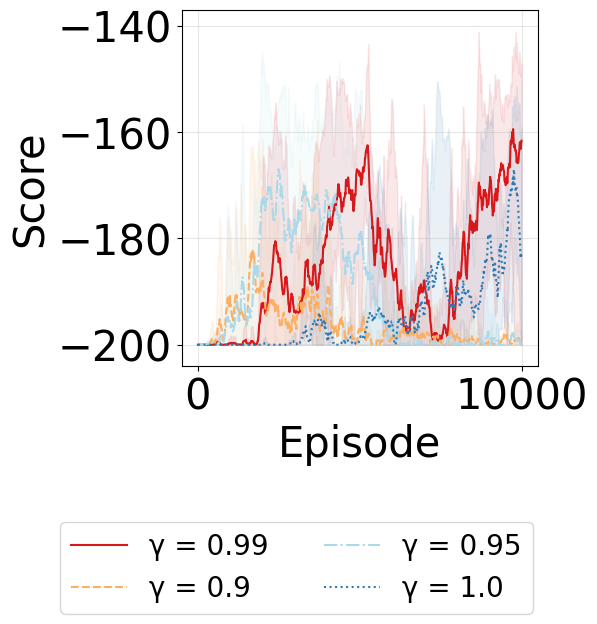

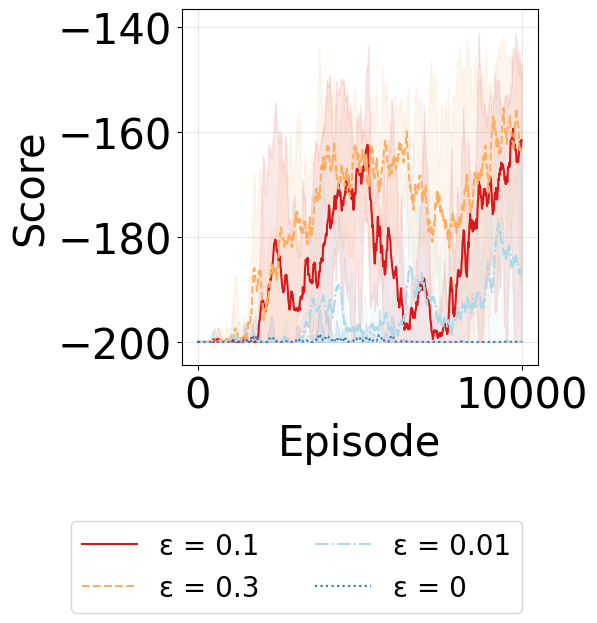

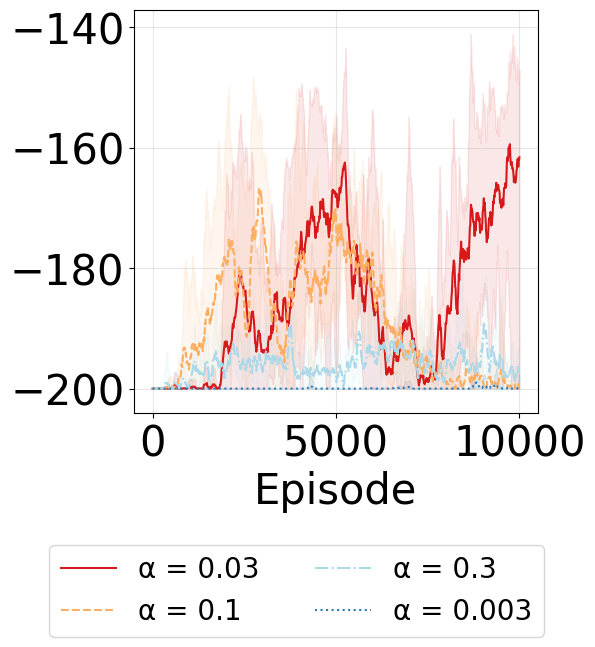

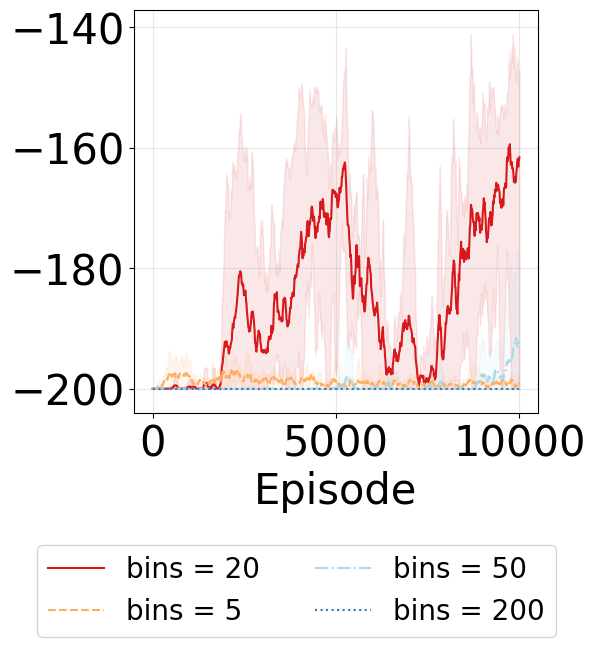

In [ ]:
qLearningPlots = [
    {
        "variable": "gamma",
        "title": "γ",
        "values": [0.99, 0.9, 0.95, 1.0],
        "save_file_path": "notebook_figures/chapter1/Qlearning_varying_gamma.pdf"
    }, {
        "variable": "epsilon",
        "title": "ε",
        "values": [0.1, 0.3, 0.01, 0],
        "save_file_path": "notebook_figures/chapter1/Qlearning_varying_epsilon.pdf"
    }, {
        "variable": "lr",
        "title": "α",
        "values": [0.03, 0.1, 0.3, 0.003],
        "save_file_path": "notebook_figures/chapter1/Qlearning_varying_alpha.pdf"
    }, {
        "variable": "num_bins",
        "title": "bins",
        "values": [20, 5, 50, 200],
        "save_file_path": "notebook_figures/chapter1/Qlearning_varying_num_bins.pdf"
    }
]
for index,plot in enumerate(qLearningPlots):

    configs = []
    for value in plot["values"]:
        config = {
            "label": f"{plot["title"]} = {value}",
            "agent_name": "QLearning",
            "agent_params": {"num_bins": 20, "lr": 0.03, "gamma": 0.99, "epsilon": 0.1},
        }
        config["agent_params"][plot["variable"]] = value
        configs.append(config)

    plot_configurations(
        results=results,
        env_name="MountainCar-v0",
        metric="valid_smooth_score",
        configs=configs,
        
        ylabel="Score" if index in [0,1] else None,
        n_col_legend=2,
        save_file_path=plot["save_file_path"],
        y_margin=1
    )

PPO On walker2d with more episodes

In [ ]:
variations = {
    "seed": [i for i in range(nb_seeds)],
    "env_name": ["Walker2d-v5"],
    "agent_name": ["PPO"],

    "agent_grids": {
        "PPO": {
            "hidden_layer": [1, 2],
            "hidden_size": [64],
            "lr": [3e-4]
        },
    }
}

create_tasks(tasks, results, base_params, variations, nb_train_episodes=nb_episodes)

Creation of task completed.
Addition of 10 tasks for a total of 10
Skipped 0 because dupplicated


PPO Training

In [ ]:
variations = {
    "seed": [i for i in range(nb_seeds)],
    "env_name": ["MountainCar-v0", "LunarLander-v3"],
    "agent_name": ["PPO"],

    "agent_grids": {
        "PPO": {
            "hidden_layer": [1, 2],
            "hidden_size": [64],
            "lr": [3e-3]
        },
    }
}

create_tasks(tasks, results, base_params, variations, nb_train_episodes=nb_episodes)

Creation of task completed.
Addition of 20 tasks for a total of 30
Skipped 0 because dupplicated


DQN Training

In [ ]:
variations = {
    "seed": [i for i in range(nb_seeds)],
    "env_name": ["MountainCar-v0", "LunarLander-v3"],
    "agent_name": ["DQN"],

    "agent_grids": {
        "DQN": {
            "hidden_layer": [1, 2],
            "hidden_size": [64],
            "lr": [3e-3]
        },
    }
}

create_tasks(tasks, results, base_params, variations, nb_train_episodes=nb_episodes)

Creation of task completed.
Addition of 20 tasks for a total of 50
Skipped 0 because dupplicated


Train PPO and DQN simultenaously

In [ ]:
train_on_tasks(results, tasks, 10)

Launching 50 experiments


[Parallel(n_jobs=10)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done   5 tasks      | elapsed: 129.9min
[Parallel(n_jobs=10)]: Done  12 tasks      | elapsed: 166.7min
[Parallel(n_jobs=10)]: Done  21 tasks      | elapsed: 220.4min
[Parallel(n_jobs=10)]: Done  30 tasks      | elapsed: 260.9min
[Parallel(n_jobs=10)]: Done  37 out of  50 | elapsed: 275.2min remaining: 96.7min
[Parallel(n_jobs=10)]: Done  43 out of  50 | elapsed: 344.4min remaining: 56.1min
[Parallel(n_jobs=10)]: Done  50 out of  50 | elapsed: 350.3min finished


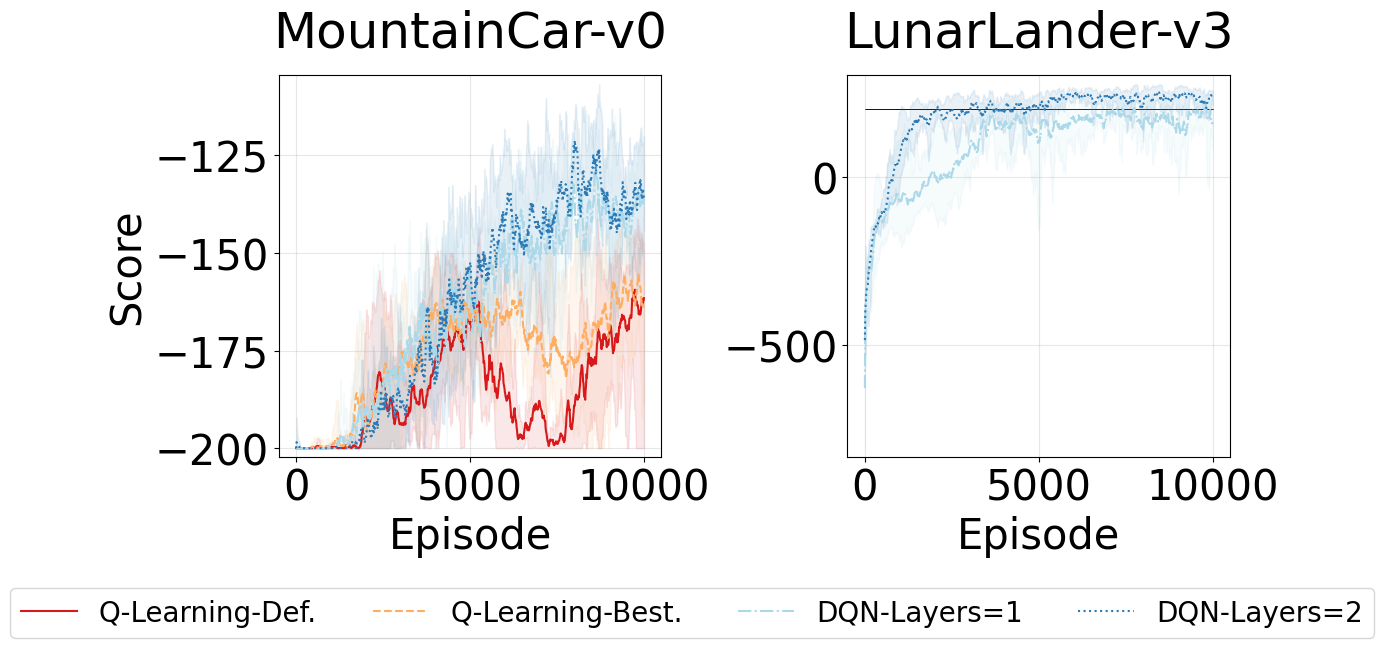

In [ ]:
configs = [
    {
        "label": f"Q-Learning-Def.",
        "agent_name": "QLearning",
        "agent_params": {"num_bins": 20, "lr": 0.03, "gamma": 0.99, "epsilon": 0.1},
    }, 
    {
        "label": f"Q-Learning-Best.",
        "agent_name": "QLearning",
        "agent_params": {"num_bins": 20, "lr": 0.03, "gamma": 0.99, "epsilon": 0.3},
    }, 
    {
        "label": f"DQN-Layers=1",
        "agent_name": "DQN",
        "agent_params": {"hidden_layer":1, "lr": 3e-3},
    }, 
    {
        "label": f"DQN-Layers=2",
        "agent_name": "DQN",
        "agent_params": {"hidden_layer":2, "lr": 3e-3},
    }, 
]

plot_configurations(
    results=results,
    env_name=["MountainCar-v0", "LunarLander-v3"],
    metric="valid_smooth_score",
    configs=configs,
    ylabel="Score",
    n_col_legend=4,
    save_file_path="notebook_figures/chapter1/DQN_score.pdf",
    title=["MountainCar-v0", "LunarLander-v3"],
    y_margin=0.3
)

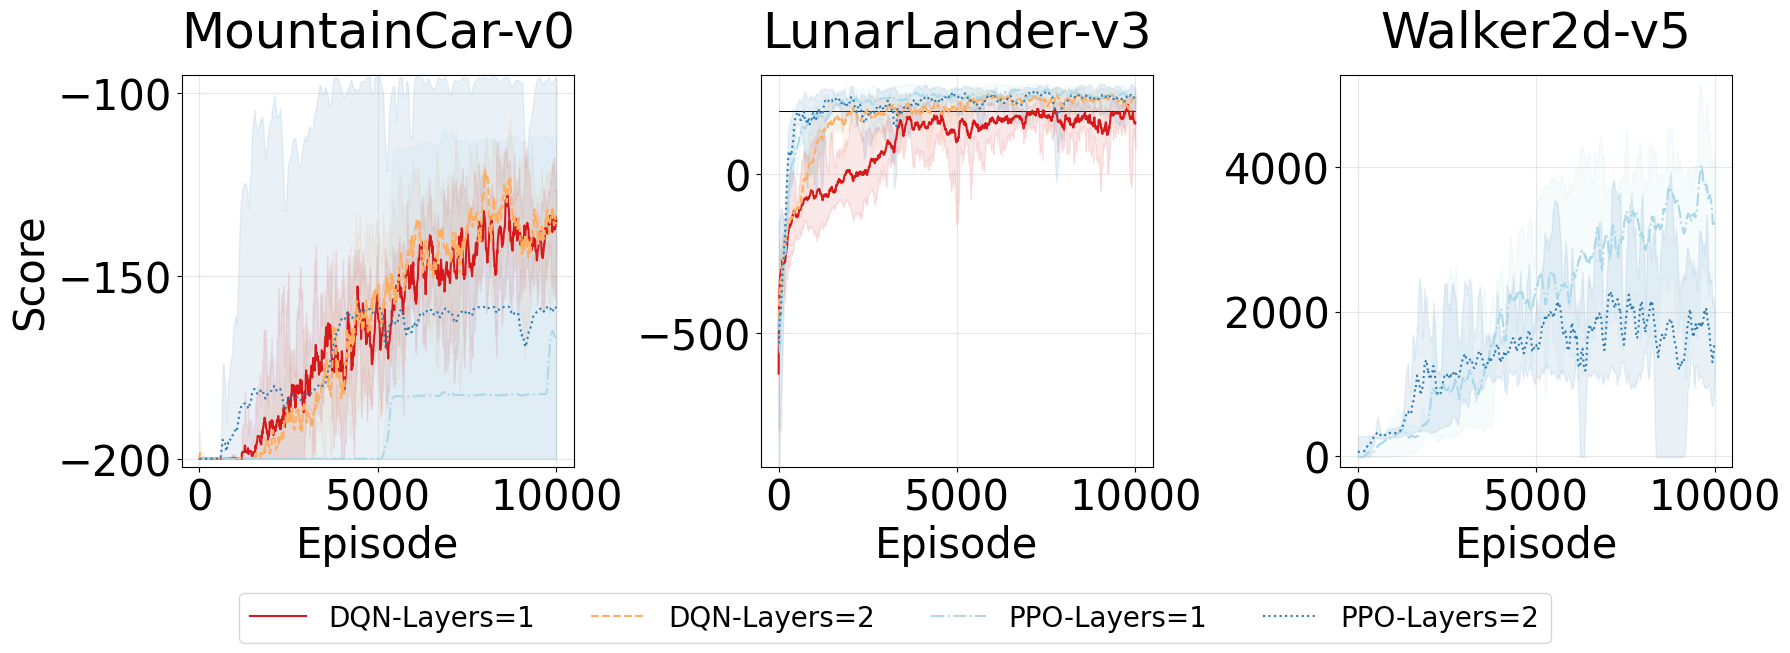

In [ ]:
configs = [
    {
        "label": f"DQN-Layers=1",
        "agent_name": "DQN",
        "agent_params": {"hidden_layer":1, "lr": 3e-3},
    }, 
    {
        "label": f"DQN-Layers=2",
        "agent_name": "DQN",
        "agent_params": {"hidden_layer":2, "lr": 3e-3},
    }, 
    {
        "label": f"PPO-Layers=1",
        "agent_name": "PPO",
        "agent_params": {"hidden_layer":1},
    }, 
    {
        "label": f"PPO-Layers=2",
        "agent_name": "PPO",
        "agent_params": {"hidden_layer":2},
    }, 
]

plot_configurations(
    results=results,
    env_name=["MountainCar-v0", "LunarLander-v3", "Walker2d-v5"],
    metric="valid_smooth_score",
    configs=configs,
    ylabel="Score",
    n_col_legend=4,
    save_file_path="notebook_figures/chapter1/PPO_score.pdf",
    title=["MountainCar-v0", "LunarLander-v3", "Walker2d-v5"],
    y_margin=0.3
)

In [ ]:
walker_results = [r for r in results if r["env_name"] == "Walker2d-v5"]

In [ ]:
test(walker_results[0]["agent"], "Walker2d-v5", 0, True)

### Testing the GP model from second notebook
Its easier to test here

Here its LGP on Lunar

In [ ]:
class LunarLanderNaiveAgent(Agent):
 

    def execute(self, state, training=False):
        r0 = state[4] + state[3] + state[7]
        r1 = 2 * (state[0] -state[4])
        r2 = np.log(abs(state[3] - max(state[7], state[4])) + 1e-10) + 1
        r3 = max(state[4], np.log(1e-10))
        
        action = np.argmax(np.array([r0, r1, r2, r3]))

        return action, {}

    
    def remember(self, state, action, reward, next_state, execution_info):
        pass
    def update(self):
        pass
    def get_additional_metrics(self):
        pass
    def after_train_clean(self):
        pass

In [ ]:
naiveAgent = LunarLanderNaiveAgent()
score_naive_lunar = []
for i in range(10):
    score_naive_lunar.append(test(naiveAgent, "LunarLander-v3", i+100, False, verbose=True))

248.61141736558147
279.034735361629
258.30021816789497
269.48515760596626
103.63536608667438
271.9621856418803
-17.053070757629328
223.49520446093373
146.25577679027666
259.42776053844057


Now TGP/CGP/LGP on mountain car

In [ ]:
class MountainCarTGP(Agent):
 

    def execute(self, state, training=False):
        a = 1 + state[0]
        b = max(a, state[1])
        c = 1 if abs(state[1]) < 1e-10 else b / state[1]
        d = c - state[0]
        e = int(np.round(np.clip(d, 0, 2)))
        return e, {}

    
    def remember(self, state, action, reward, next_state, execution_info):
        pass
    def update(self):
        pass
    def get_additional_metrics(self):
        pass
    def after_train_clean(self):
        pass

In [ ]:
class MountainCarLGP(Agent):
 

    def execute(self, state, training=False):
        r0 = 3 * state[1] + 2 *state[0] + 2
        r1 = np.log(abs(state[0]) + 1e-10)
        a = 4 * state[1] + 2 *state[0] + 2
        r2 = 1 if abs(state[1]) < 1e-10 else a / state[1]
        
        action = np.argmax(np.array([r0, r1, r2]))
        return action, {}

    
    def remember(self, state, action, reward, next_state, execution_info):
        pass
    def update(self):
        pass
    def get_additional_metrics(self):
        pass
    def after_train_clean(self):
        pass

In [ ]:
class MountainCarCGP(Agent):
 

    def execute(self, state, training=False):
        r0 = state[0] - state[1]
        r1 = max(state[0]-state[1],state[0])
        r2 = 2 * state[1] + state[0]
        
        action = np.argmax(np.array([r0, r1, r2]))
        return action, {}

    
    def remember(self, state, action, reward, next_state, execution_info):
        pass
    def update(self):
        pass
    def get_additional_metrics(self):
        pass
    def after_train_clean(self):
        pass

In [ ]:
class MountainCarNaive(Agent):
 

    def execute(self, state, training=False):
        if state[1] >0:
            return 2, {}
        else:
            return 0, {}

    
    def remember(self, state, action, reward, next_state, execution_info):
        pass
    def update(self):
        pass
    def get_additional_metrics(self):
        pass
    def after_train_clean(self):
        pass

In [ ]:
naiveAgent = MountainCarLGP()
lgpAgent = MountainCarLGP()
tgpAgent = MountainCarTGP()
cgpAgent = MountainCarCGP()
score_cgp = []
score_naive = []
score_lgp = []
score_tgp = []
for i in range(30):
    score_naive.append(test(naiveAgent, "MountainCar-v0", i, False, verbose=False))
    score_lgp.append(test(lgpAgent, "MountainCar-v0", i, False, verbose=False))
    score_tgp.append(test(tgpAgent, "MountainCar-v0", i, False, verbose=False))
    score_cgp.append(test(cgpAgent, "MountainCar-v0", i, False, verbose=True))

In [ ]:
print(sum(score_naive) / 30)
print(sum(score_lgp) / 30)
print(sum(score_tgp) / 30)
print(sum(score_cgp) / 30)

-109.2
-109.2
-108.83333333333333
-126.46666666666667


In [ ]:
for i in range(30):
    print(score_naive[i], score_lgp[i], score_tgp[i], score_cgp[i])

-101.0 -101.0 -101.0 -101.0
-172.0 -172.0 -170.0 -169.0
-116.0 -116.0 -115.0 -156.0
-118.0 -118.0 -116.0 -153.0
-87.0 -87.0 -87.0 -87.0
-90.0 -90.0 -91.0 -90.0
-179.0 -179.0 -177.0 -176.0
-102.0 -102.0 -103.0 -102.0
-116.0 -116.0 -115.0 -158.0
-88.0 -88.0 -89.0 -88.0
-86.0 -86.0 -87.0 -86.0
-118.0 -118.0 -116.0 -153.0
-116.0 -116.0 -115.0 -155.0
-88.0 -88.0 -89.0 -88.0
-89.0 -89.0 -90.0 -89.0
-96.0 -96.0 -96.0 -96.0
-122.0 -122.0 -124.0 -122.0
-89.0 -89.0 -90.0 -89.0
-116.0 -116.0 -115.0 -160.0
-116.0 -116.0 -115.0 -161.0
-117.0 -117.0 -115.0 -156.0
-91.0 -91.0 -92.0 -91.0
-116.0 -116.0 -115.0 -159.0
-96.0 -96.0 -96.0 -96.0
-116.0 -116.0 -115.0 -158.0
-117.0 -117.0 -115.0 -154.0
-117.0 -117.0 -115.0 -166.0
-95.0 -95.0 -96.0 -95.0
-88.0 -88.0 -89.0 -88.0
-118.0 -118.0 -116.0 -152.0


### "Interpretability" of PPO

In [ ]:
for i, r in enumerate(results):
    if(r["agent_name"] == "PPO"):
        print(i, r["seed"], r["agent_name"], r["env_name"], r["agent_params"]["lr"], r["agent_params"]["hidden_layer"], r["logs"]["valid_smooth_score"][9999])
#print(results[0])


65 0 PPO Walker2d-v5 0.0003 1 4128.316170305611
66 1 PPO Walker2d-v5 0.0003 1 3955.665973956466
67 2 PPO Walker2d-v5 0.0003 1 2336.717519921542
68 3 PPO Walker2d-v5 0.0003 1 2741.4119476215074
69 4 PPO Walker2d-v5 0.0003 1 3173.177943801192
70 0 PPO Walker2d-v5 0.0003 2 1159.8659087989556
71 1 PPO Walker2d-v5 0.0003 2 2095.759688342583
72 2 PPO Walker2d-v5 0.0003 2 1094.5374550676534
73 3 PPO Walker2d-v5 0.0003 2 1751.2382872192622
74 4 PPO Walker2d-v5 0.0003 2 1764.4457246285274
75 0 PPO MountainCar-v0 0.003 1 -112.47
76 1 PPO MountainCar-v0 0.003 1 -200.0
77 2 PPO MountainCar-v0 0.003 1 -200.0
78 3 PPO MountainCar-v0 0.003 1 -123.27000000000001
79 4 PPO MountainCar-v0 0.003 1 -200.0
80 0 PPO MountainCar-v0 0.003 2 -98.94
81 1 PPO MountainCar-v0 0.003 2 -95.78999999999999
82 2 PPO MountainCar-v0 0.003 2 -200.0
83 3 PPO MountainCar-v0 0.003 2 -200.0
84 4 PPO MountainCar-v0 0.003 2 -200.0
85 0 PPO LunarLander-v3 0.003 1 267.4849502602257
86 1 PPO LunarLander-v3 0.003 1 214.9736741952560

In [ ]:
results[77]["agent"].actor


Network(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=3, bias=True)
  )
)

In [ ]:
torch.set_printoptions(sci_mode=False)

C:\Users\qvacher\AppData\Local\Temp\ipykernel_20216\2389913262.py:94: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


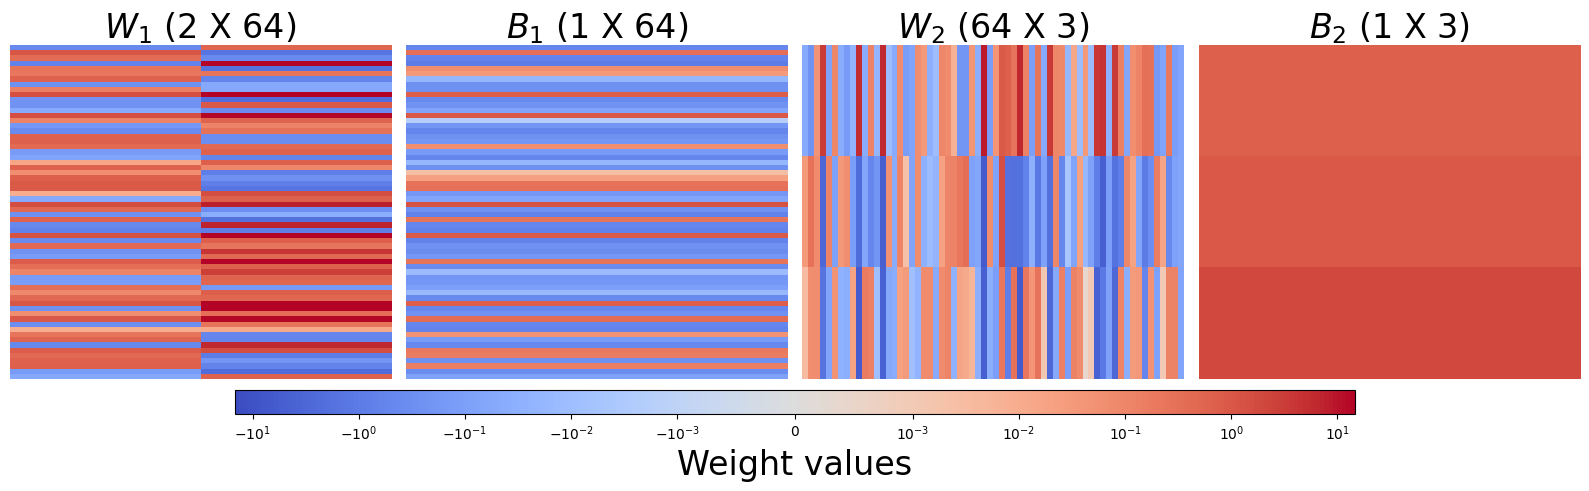

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import SymLogNorm


def to_np(t):
    t = t.detach().cpu().float()
    return t.numpy()


def make_2d(t):
    """
    Ensures imshow-compatible shape without altering values.
    """
    t = t.detach().cpu().float()

    if t.ndim == 1:
        t = t.unsqueeze(1)   # <-- KEY FIX: (N,) -> (N,1)

    return t.numpy()


actor = results[77]["agent"].actor
params = dict(actor.named_parameters())

weight_keys = sorted([k for k in params if "weight" in k])
bias_keys   = sorted([k for k in params if "bias" in k])

W1 = params[weight_keys[0]]
B1 = params[bias_keys[0]]
W2 = params[weight_keys[1]]
B2 = params[bias_keys[1]]

# -------------------------
# GLOBAL SCALE (IMPORTANT)
# -------------------------

all_vals = np.concatenate([
    to_np(W1).ravel(),
    to_np(B1).ravel(),
    to_np(W2).ravel(),
    to_np(B2).ravel()
])

vmax = np.percentile(np.abs(all_vals), 99)
vmin = -vmax

norm = SymLogNorm(
    linthresh=1e-3,
    linscale=1.0,
    vmin=vmin,
    vmax=vmax
)

cmap = "coolwarm"

# -------------------------
# SINGLE FIGURE (1×4)
# -------------------------

fig, axs = plt.subplots(1, 4, figsize=(16, 4))

m0 = axs[0].imshow(make_2d(W1), cmap=cmap, norm=norm, aspect="auto")
axs[0].set_title(r"$W_1$ (2 X 64)", fontsize=24)
axs[0].axis("off")

m1 = axs[1].imshow(make_2d(B1), cmap=cmap, norm=norm, aspect="auto")
axs[1].set_title(r"$B_1$ (1 X 64)", fontsize=24)
axs[1].axis("off")

m2 = axs[2].imshow(make_2d(W2), cmap=cmap, norm=norm, aspect="auto")
axs[2].set_title(r"$W_2$ (64 X 3)", fontsize=24)
axs[2].axis("off")

m3 = axs[3].imshow(make_2d(B2), cmap=cmap, norm=norm, aspect="auto")
axs[3].set_title(r"$B_2$ (1 X 3)", fontsize=24)
axs[3].axis("off")

# -------------------------
# SPACE FOR COLORBAR
# -------------------------
plt.tight_layout(rect=[0, 0.12, 1, 1])  # leave space at bottom

# -------------------------
# HORIZONTAL COLORBAR (BOTTOM)
# -------------------------
cbar_ax = fig.add_axes([0.15, -0.05, 0.7, 0.06])  # [left, bottom, width, height]

cbar = fig.colorbar(m3, cax=cbar_ax, orientation="horizontal")
cbar.set_label("Weight values", fontsize=24)


plt.tight_layout()
plt.savefig(
    "notebook_figures/chapter1/ppo_interpretabilinaze.pdf",
    dpi=300,
    bbox_inches="tight",
)
plt.show()